# Hilbert–Huang Transform (HHT)

> **Primary reference (this repo)**: Zeiler, A. et al. (2010). *Empirical Mode Decomposition — An Introduction*. IEEE (sections on HHT).
>
> **Foundational paper**: Huang, N. E. et al. (1998). *The empirical mode decomposition and the Hilbert spectrum for nonlinear and non-stationary time series analysis*. Proc. R. Soc. Lond. A.

The **Hilbert–Huang Transform** combines:

1. **EMD** — decompose a nonlinear / non-stationary signal into IMFs;  
2. **Hilbert spectral analysis** — compute instantaneous amplitude and frequency of each IMF, then form the time–frequency **Hilbert spectrum** $H(t,f)$.

This notebook provides detailed examples and visualizations with PySDKit’s `HHT` class.

---

## Contents

1. From EMD to HHT  
2. Hilbert transform and the analytic signal  
3. Instantaneous amplitude and frequency  
4. Why IMFs are required before Hilbert analysis  
5. Experiment 1: AM–FM chirp mixture (`test_hht`)  
6. Experiment 2: Hilbert spectrum visualization  
7. Experiment 3: Nonlinear Duffing-type oscillator  
8. Experiment 4: Comparison with a spectrogram  
9. Summary  


## 1. From EMD to HHT

After EMD,
$$
x(t)=\sum_n x_n(t)+r(t),
$$
each IMF $x_n$ is (approximately) a narrowband, zero-mean oscillation. Applying the Hilbert transform to IMF $n$ yields the analytic signal (paper Eqs. (2)–(5))
$$
z_n(t)=x_n(t)+j\,\mathcal{H}\{x_n\}(t)=a_n(t)\,e^{j\theta_n(t)},
$$
with
$$
a_n(t)=\lvert z_n(t)\rvert,\qquad
\omega_n(t)=\frac{\mathrm{d}\theta_n(t)}{\mathrm{d}t}.
$$

The signal then admits a **generalized Fourier expansion** (paper Eqs. (8)–(9)):
$$
x(t)=\mathrm{Re}\left\{\sum_n a_n(t)\exp\Big(j\int\omega_n(t)\,\mathrm{d}t\Big)\right\}+r(t),
$$
where amplitudes and frequencies may vary in time — unlike classical Fourier series with constant $a_n,\omega_n$.


## 2. Hilbert transform and the analytic signal

The Hilbert transform
$$
\mathcal{H}\{x\}(t)=\frac{1}{\pi}\,\mathrm{p.v.}\int_{-\infty}^{\infty}\frac{x(\tau)}{t-\tau}\,\mathrm{d}\tau
$$
is a $90^\circ$ phase shifter. In the Fourier domain it suppresses negative frequencies of the analytic signal, giving a unilateral spectrum — the same idea that later inspired VMD’s demodulation step.


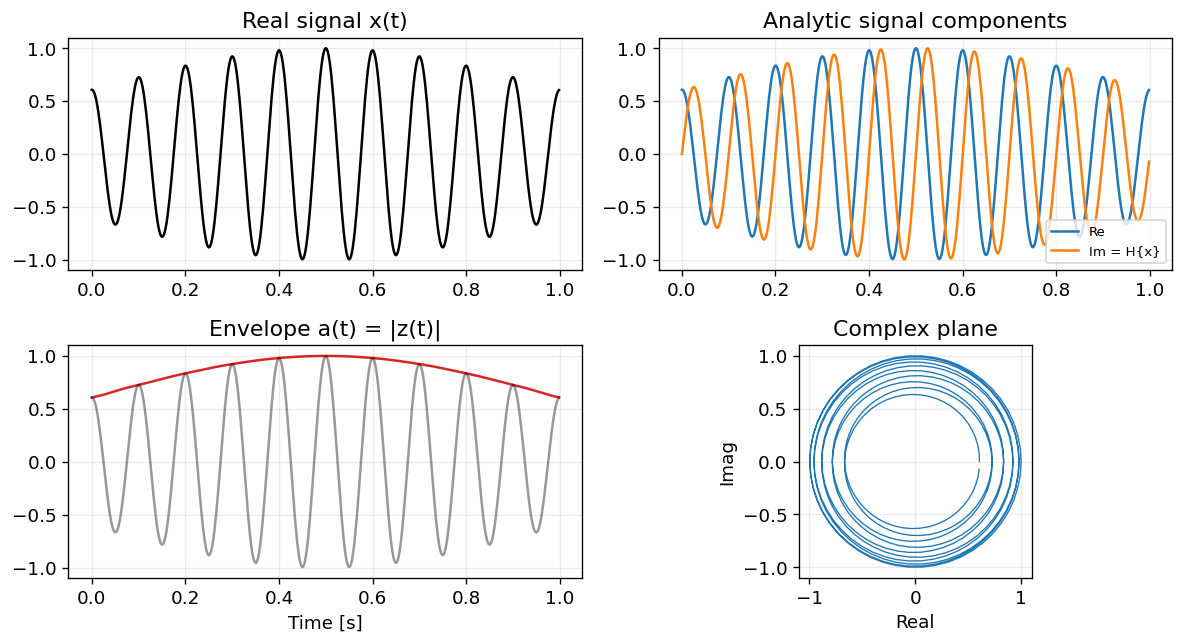

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, hilbert as sp_hilbert

from pysdkit import HHT, EMD
from pysdkit.data import test_hht, test_univariate_duffing
from pysdkit.plot import plot_IMFs, plot_HilbertSpectrum
from pysdkit.utils import hilbert_transform, hilbert_spectrum
from pysdkit._emd.hht.frequency import get_envelope_frequency

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)


def relative_error(ref, est):
    ref = np.asarray(ref, dtype=float)
    est = np.asarray(est, dtype=float)
    return np.linalg.norm(est - ref) / (np.linalg.norm(ref) + 1e-16)


# Simple tone: visualize analytic signal
fs0 = 500.0
t0 = np.arange(0, 1.0, 1.0 / fs0)
x0 = np.cos(2 * np.pi * 10 * t0) * np.exp(-2 * (t0 - 0.5) ** 2)
z0 = hilbert_transform(x0)

fig, axs = plt.subplots(2, 2, figsize=(10, 5.5))
axs[0, 0].plot(t0, x0, "k")
axs[0, 0].set_title("Real signal x(t)")
axs[0, 1].plot(t0, np.real(z0), label="Re")
axs[0, 1].plot(t0, np.imag(z0), label="Im = H{x}")
axs[0, 1].legend(fontsize=8)
axs[0, 1].set_title("Analytic signal components")
axs[1, 0].plot(t0, np.abs(z0), color="C3")
axs[1, 0].plot(t0, x0, "k", alpha=0.4)
axs[1, 0].set_title("Envelope a(t) = |z(t)|")
axs[1, 0].set_xlabel("Time [s]")
axs[1, 1].plot(np.real(z0), np.imag(z0), lw=0.8)
axs[1, 1].set_aspect("equal")
axs[1, 1].set_xlabel("Real")
axs[1, 1].set_ylabel("Imag")
axs[1, 1].set_title("Complex plane")
plt.tight_layout()
plt.show()

## 3. Instantaneous amplitude and frequency

For an analytic signal $z(t)=a(t)e^{j\theta(t)}$,
$$
a(t)=\lvert z(t)\rvert,\qquad
f(t)=\frac{1}{2\pi}\frac{\mathrm{d}\theta(t)}{\mathrm{d}t}\quad\text{(Hz)}.
$$
PySDKit’s `get_envelope_frequency` computes these for arrays of IMFs.


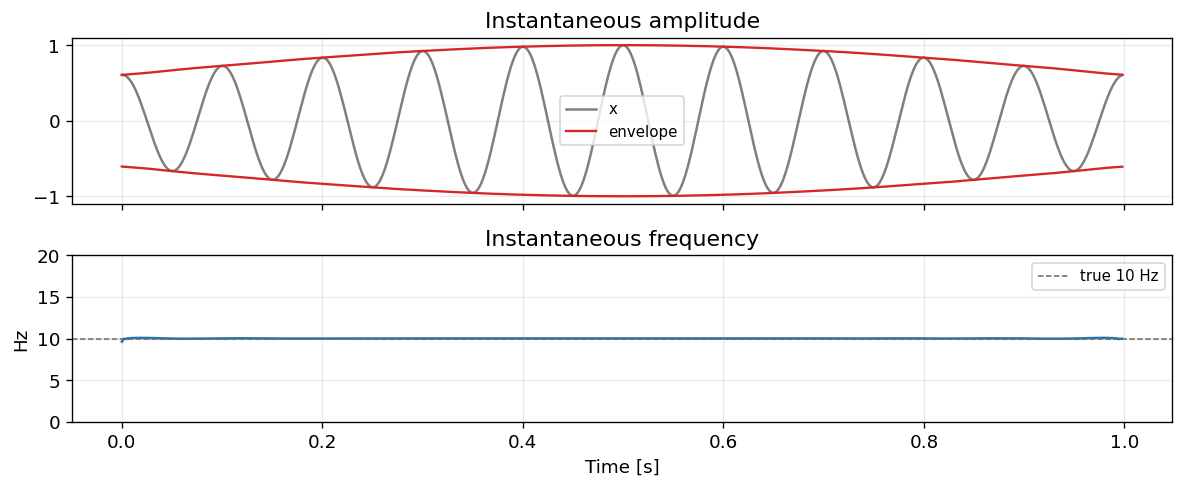

In [2]:
env0, freq0 = get_envelope_frequency(x0[None, :], fs=fs0)
env0, freq0 = env0[0], freq0[0]

fig, axs = plt.subplots(2, 1, figsize=(10, 4.2), sharex=True)
axs[0].plot(t0, x0, "k", alpha=0.5, label="x")
axs[0].plot(t0, env0, "C3", lw=1.4, label="envelope")
axs[0].plot(t0, -env0, "C3", lw=1.4)
axs[0].legend(fontsize=9)
axs[0].set_title("Instantaneous amplitude")
axs[1].plot(t0, freq0, color="C0")
axs[1].axhline(10, color="0.4", ls="--", lw=0.9, label="true 10 Hz")
axs[1].legend(fontsize=9)
axs[1].set_ylabel("Hz")
axs[1].set_xlabel("Time [s]")
axs[1].set_ylim(0, 20)
axs[1].set_title("Instantaneous frequency")
plt.tight_layout()
plt.show()

## 4. Why IMFs are required before Hilbert analysis

The Hilbert transform yields a meaningful instantaneous frequency only for **narrowband / mono-component** signals. A raw multi-component mixture produces meaningless $f(t)$. EMD’s role is to provide those mono-component IMFs.

Paper note on the Duffing oscillator: nonlinearity makes the effective stiffness — and thus the instantaneous frequency — time-varying; HHT is designed to track that.


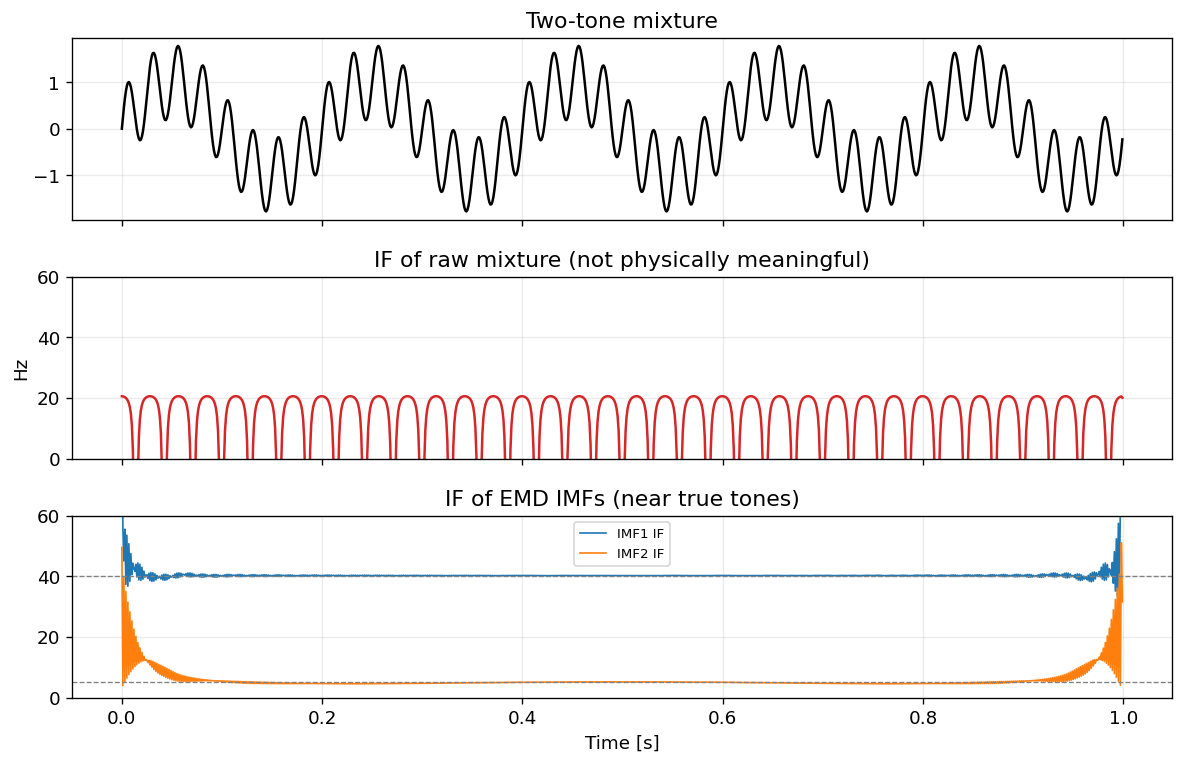

In [3]:
# Multi-component mixture WITHOUT EMD: IF is not meaningful
fs = 1000.0
t = np.arange(0, 1.0, 1.0 / fs)
mix = np.sin(2 * np.pi * 5 * t) + 0.8 * np.sin(2 * np.pi * 40 * t)
env_mix, freq_mix = get_envelope_frequency(mix[None, :], fs=fs)
freq_mix = freq_mix[0]

emd = EMD(max_imfs=3)
imfs = emd.fit_transform(mix)
env_imf, freq_imf = get_envelope_frequency(imfs, fs=fs)

fig, axs = plt.subplots(3, 1, figsize=(10, 6.5), sharex=True)
axs[0].plot(t, mix, "k")
axs[0].set_title("Two-tone mixture")
axs[1].plot(t, freq_mix, color="C3")
axs[1].set_ylabel("Hz")
axs[1].set_title("IF of raw mixture (not physically meaningful)")
axs[1].set_ylim(0, 60)
for k in range(min(2, imfs.shape[0])):
    axs[2].plot(t, freq_imf[k], lw=1.0, label=f"IMF{k+1} IF")
axs[2].axhline(5, color="0.5", ls="--", lw=0.8)
axs[2].axhline(40, color="0.5", ls="--", lw=0.8)
axs[2].legend(fontsize=8)
axs[2].set_ylim(0, 60)
axs[2].set_xlabel("Time [s]")
axs[2].set_title("IF of EMD IMFs (near true tones)")
plt.tight_layout()
plt.show()

## 5. Experiment 1: AM–FM chirp mixture (`test_hht`)

PySDKit’s `test_hht` builds two localized chirps — a quadratic chirp around 5–10 Hz and a linear chirp around 40–50 Hz — a standard non-stationary demo for HHT.


signal length: (2000,) duration [s]: 1.999


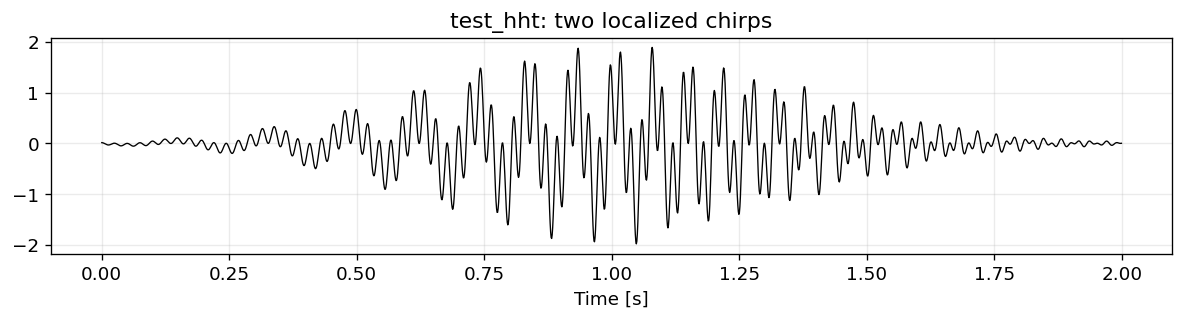

IMFs shape: (5, 2000)
relative recon. error (IMFs only): 8.662407193507339e-21


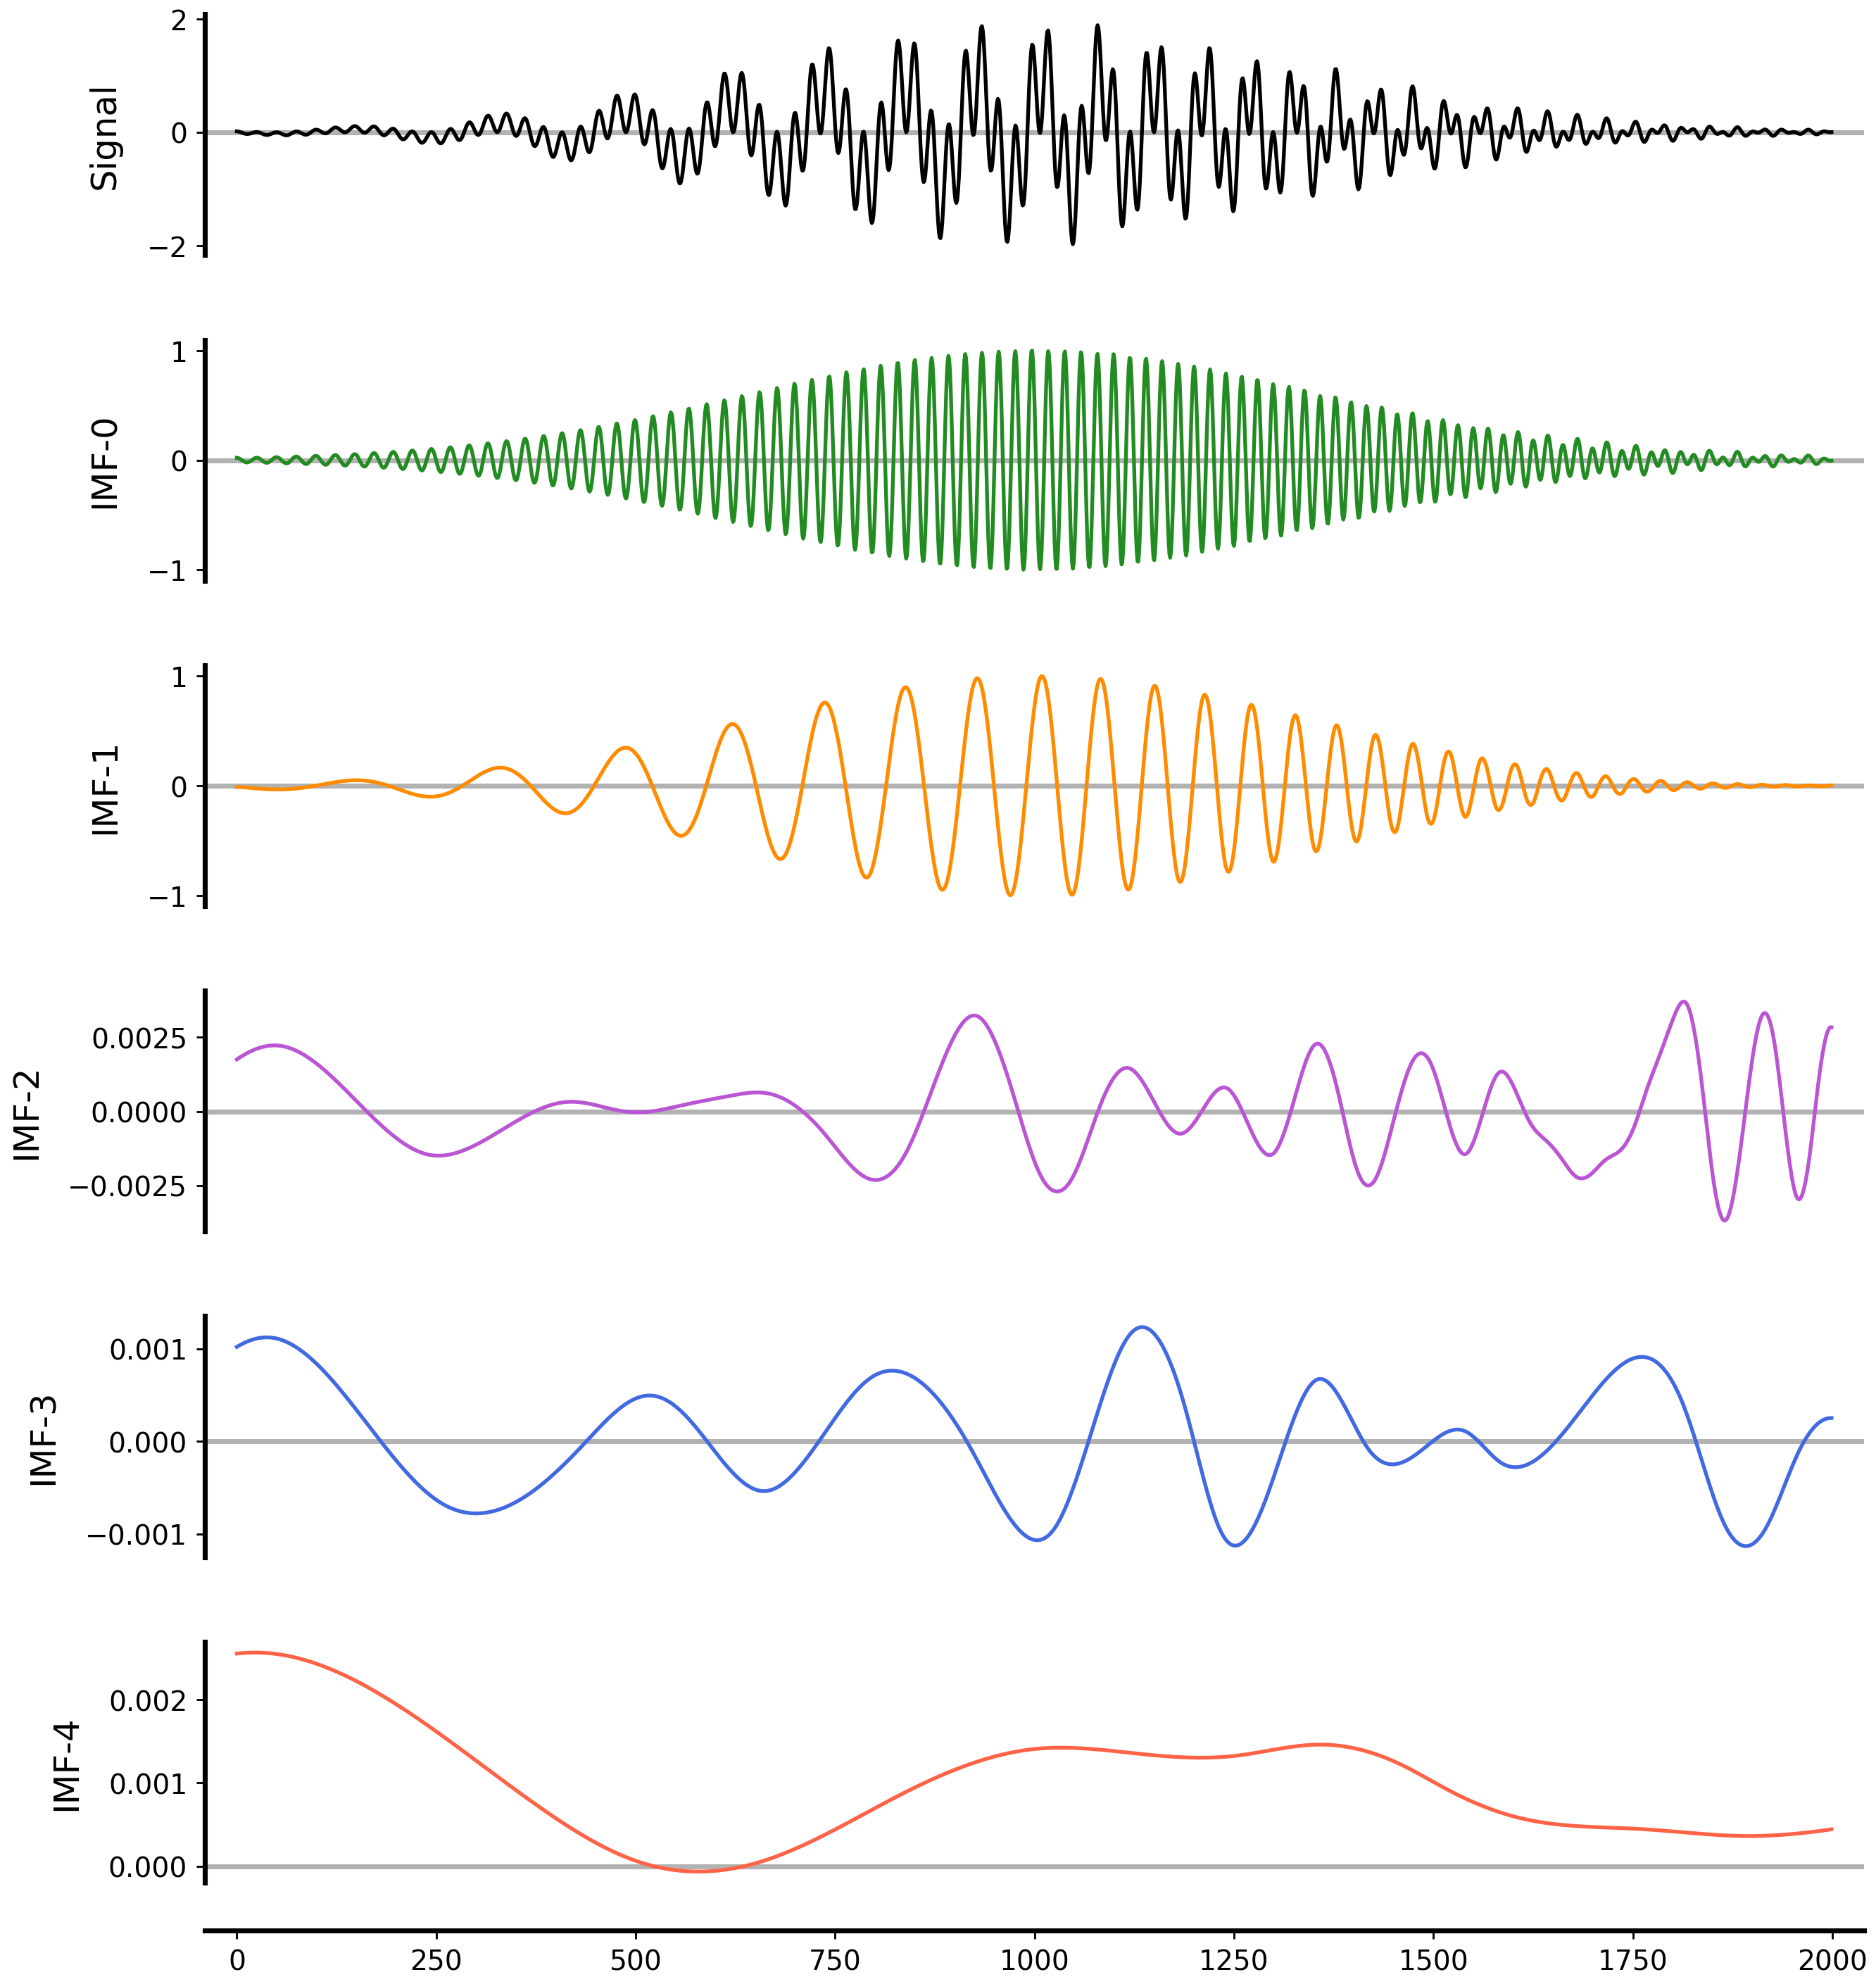

In [4]:
t, signal = test_hht(duration=2.0, sampling_rate=1000)
fs = 1000.0
print("signal length:", signal.shape, "duration [s]:", t[-1])

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.plot(t, signal, "k", lw=0.8)
ax.set_xlabel("Time [s]")
ax.set_title("test_hht: two localized chirps")
plt.tight_layout()
plt.show()

hht = HHT(algorithm="EMD", max_imfs=4)
imfs, imfs_env, imfs_freq = hht.fit_transform(signal, fs=fs, return_all=True)
print("IMFs shape:", imfs.shape)
print("relative recon. error (IMFs only):", relative_error(signal, imfs.sum(0)))

fig = plot_IMFs(signal, imfs, return_figure=True)
plt.show()

## 6. Experiment 2: Instantaneous features and Hilbert spectrum

For each IMF we plot envelope $a_n(t)$ and instantaneous frequency $f_n(t)$, then assemble the Hilbert spectrum $H(t,f)$ by accumulating $a_n^2(t)$ at coordinates $\bigl(t,f_n(t)\bigr)$.


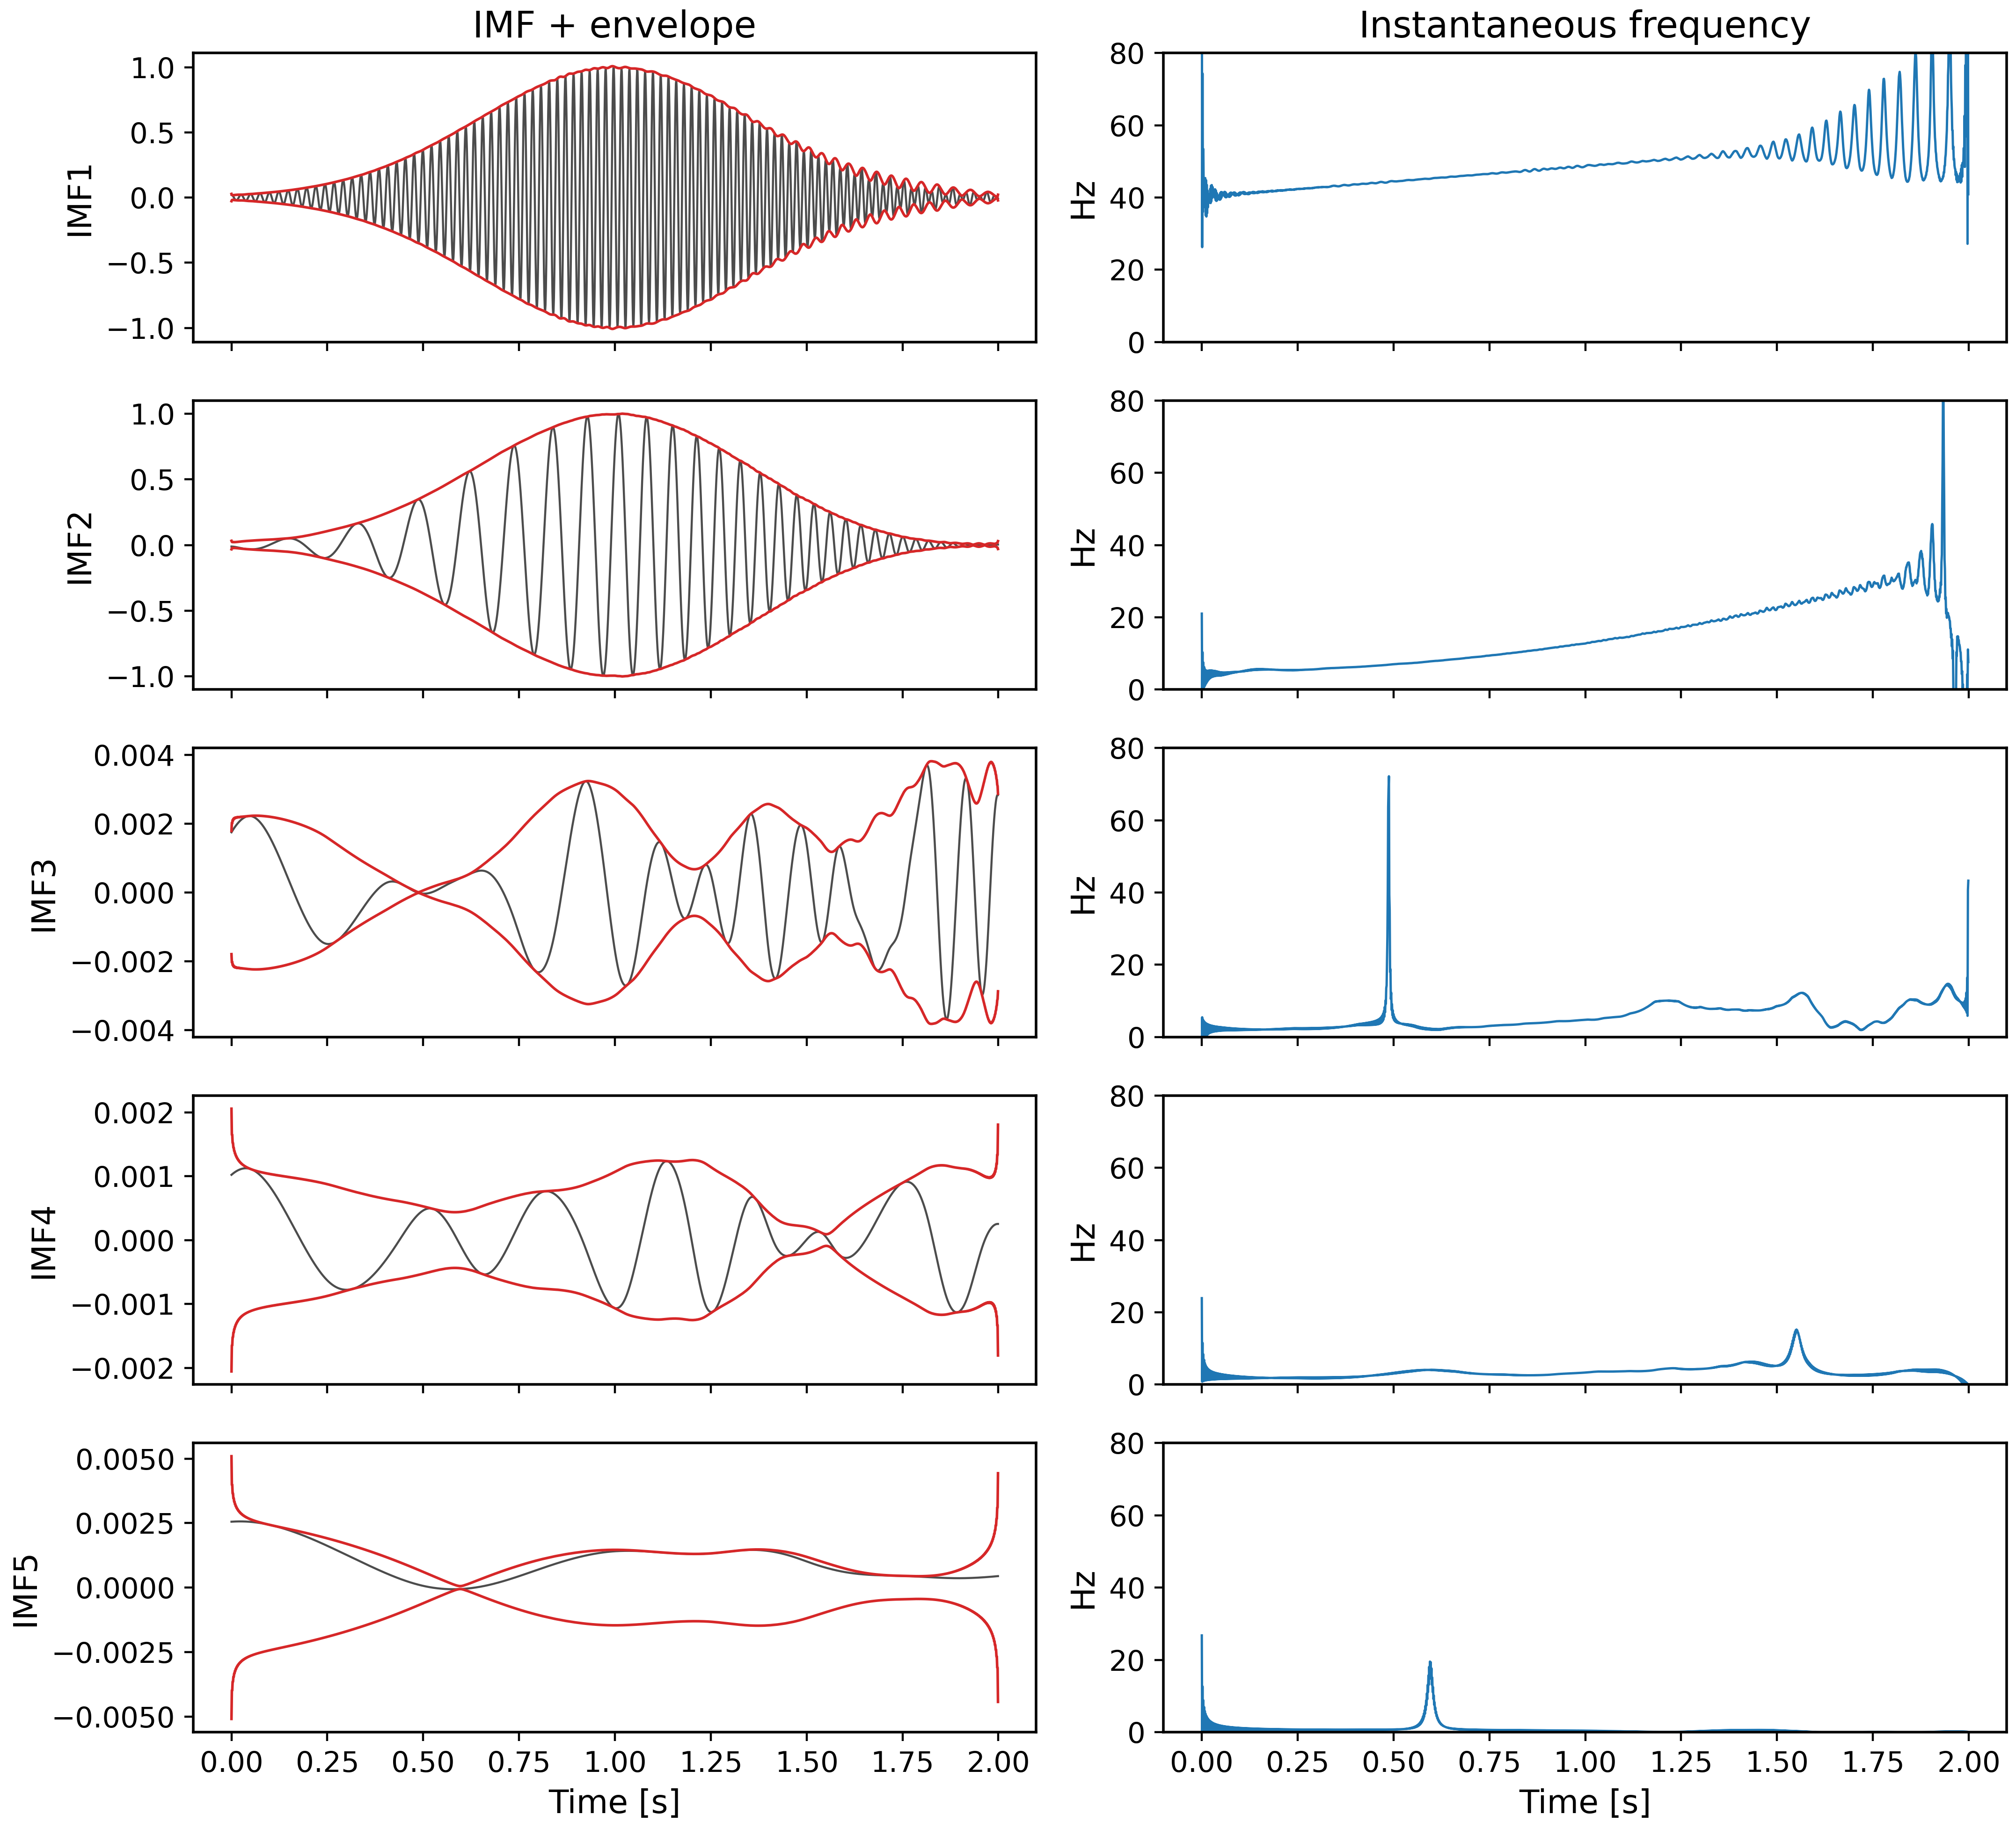

Hilbert spectrum shape (time, freq): (2001, 161)


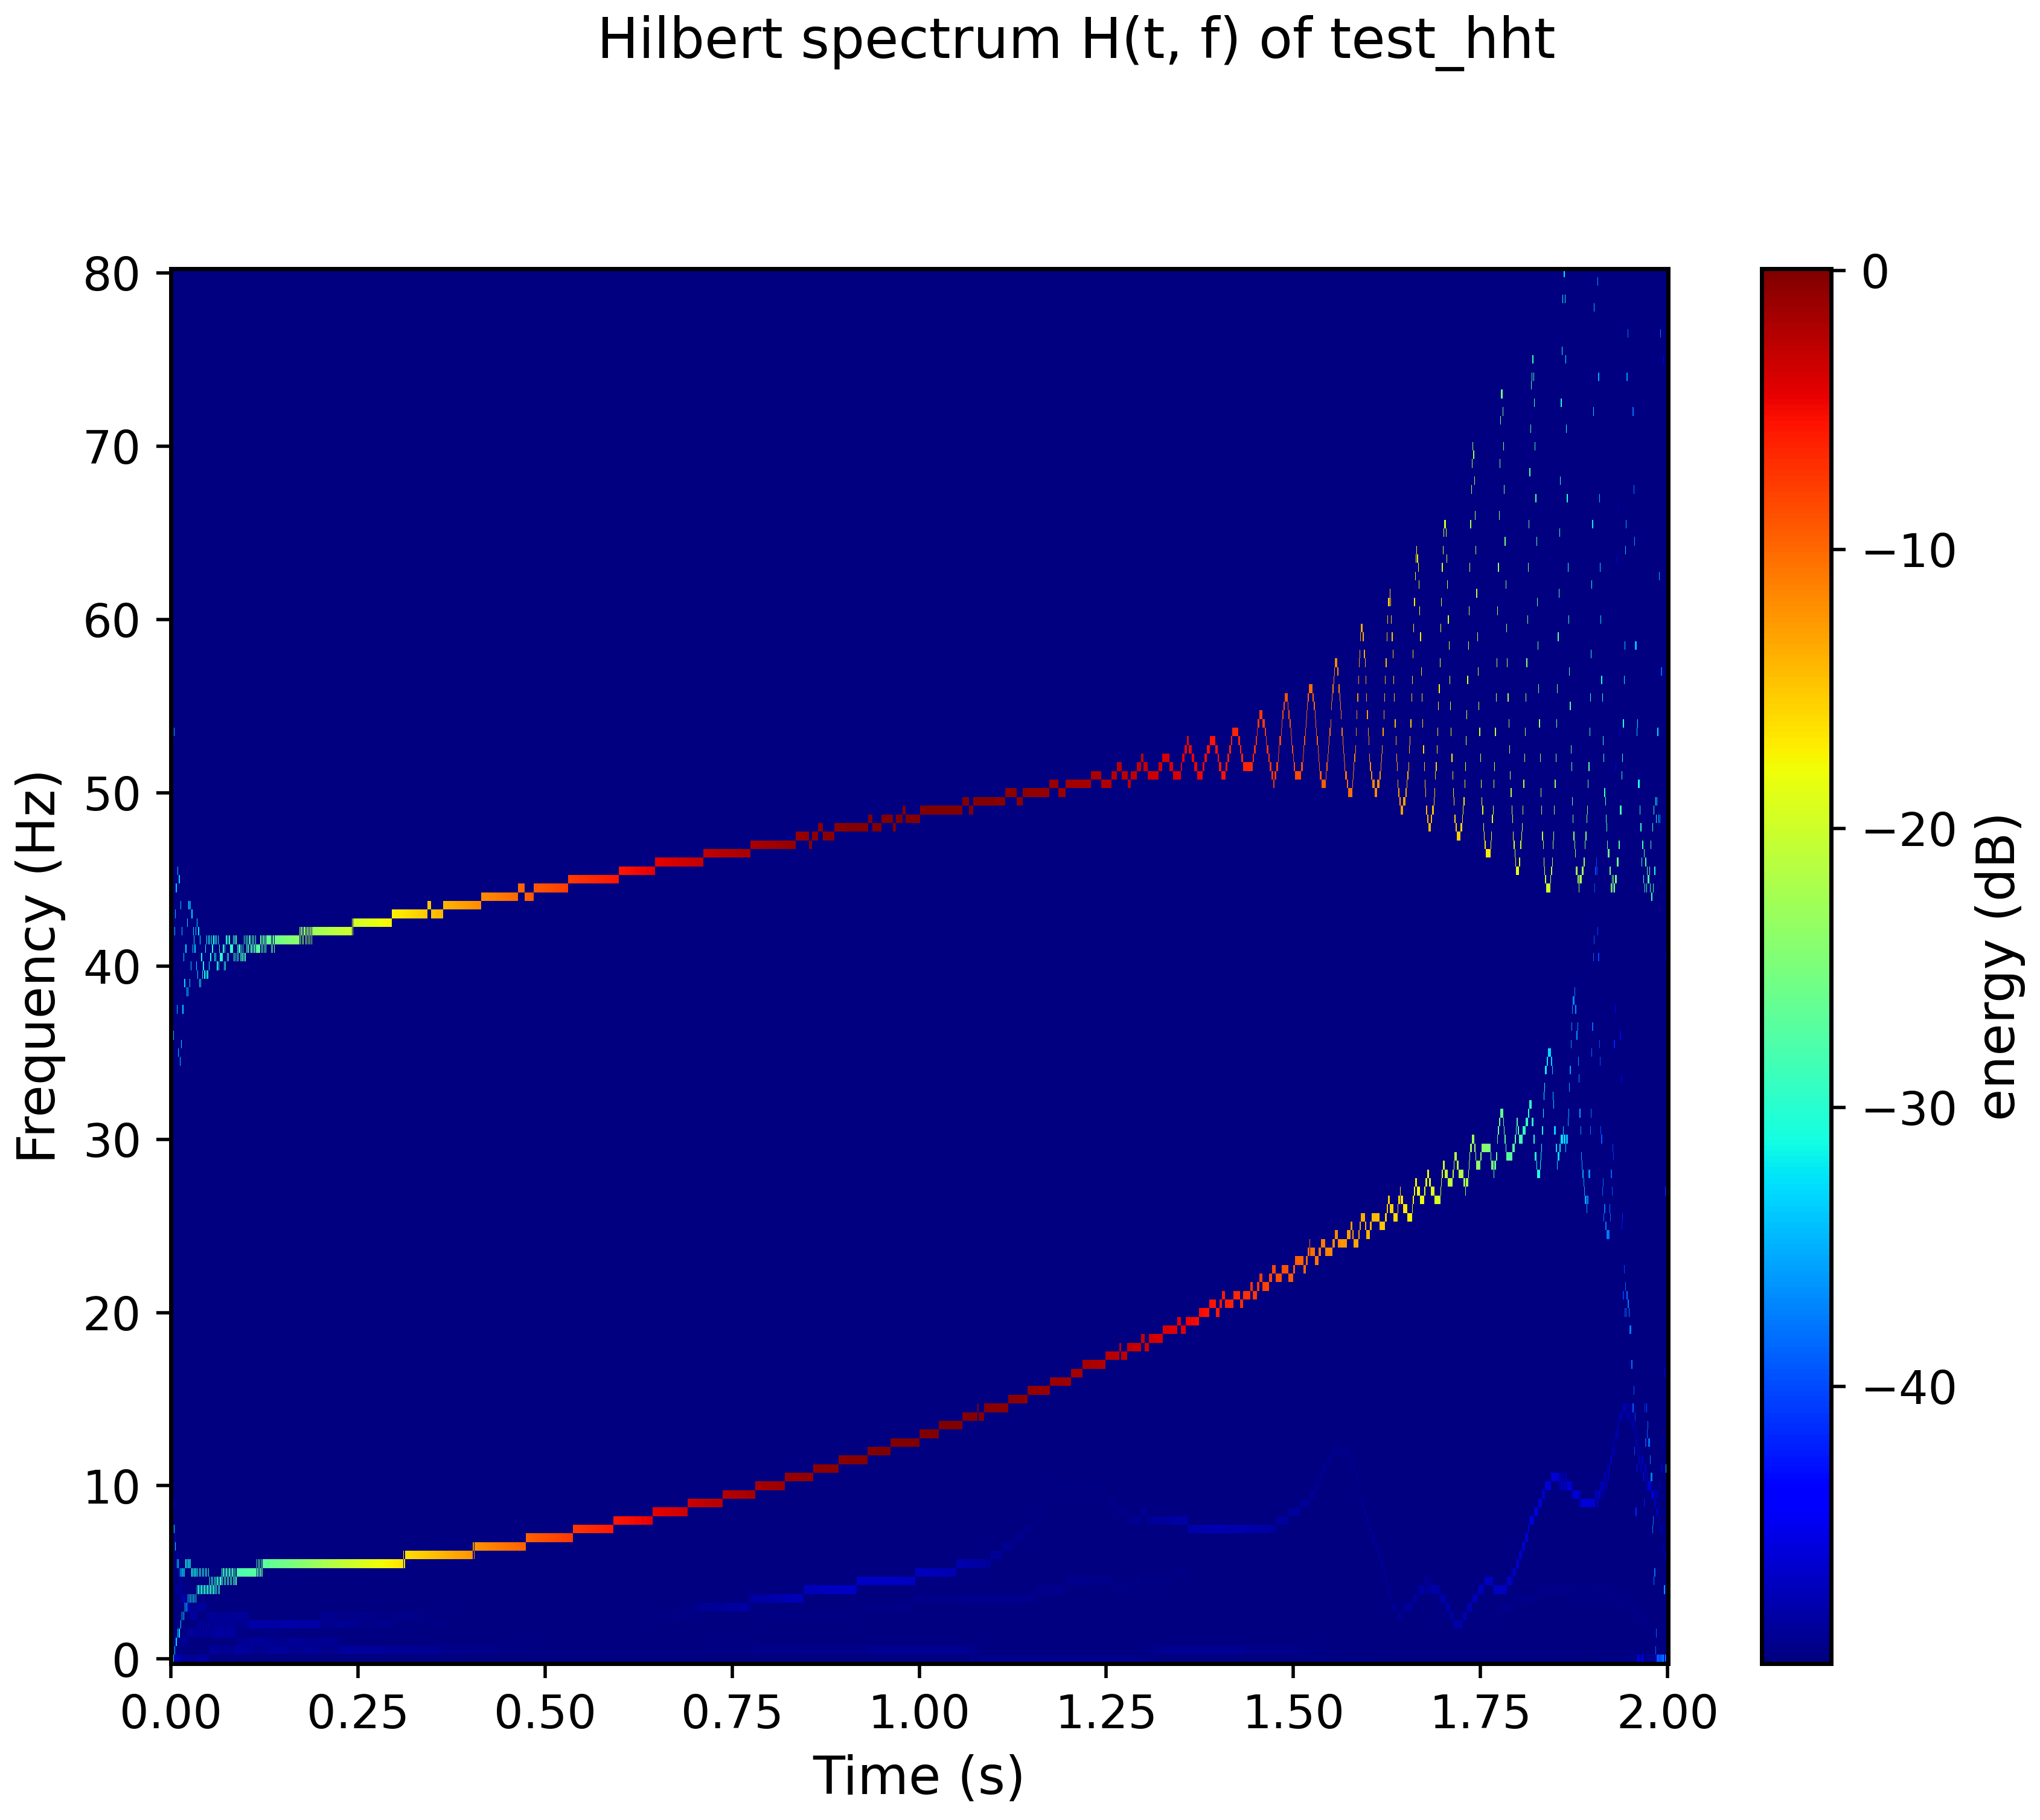

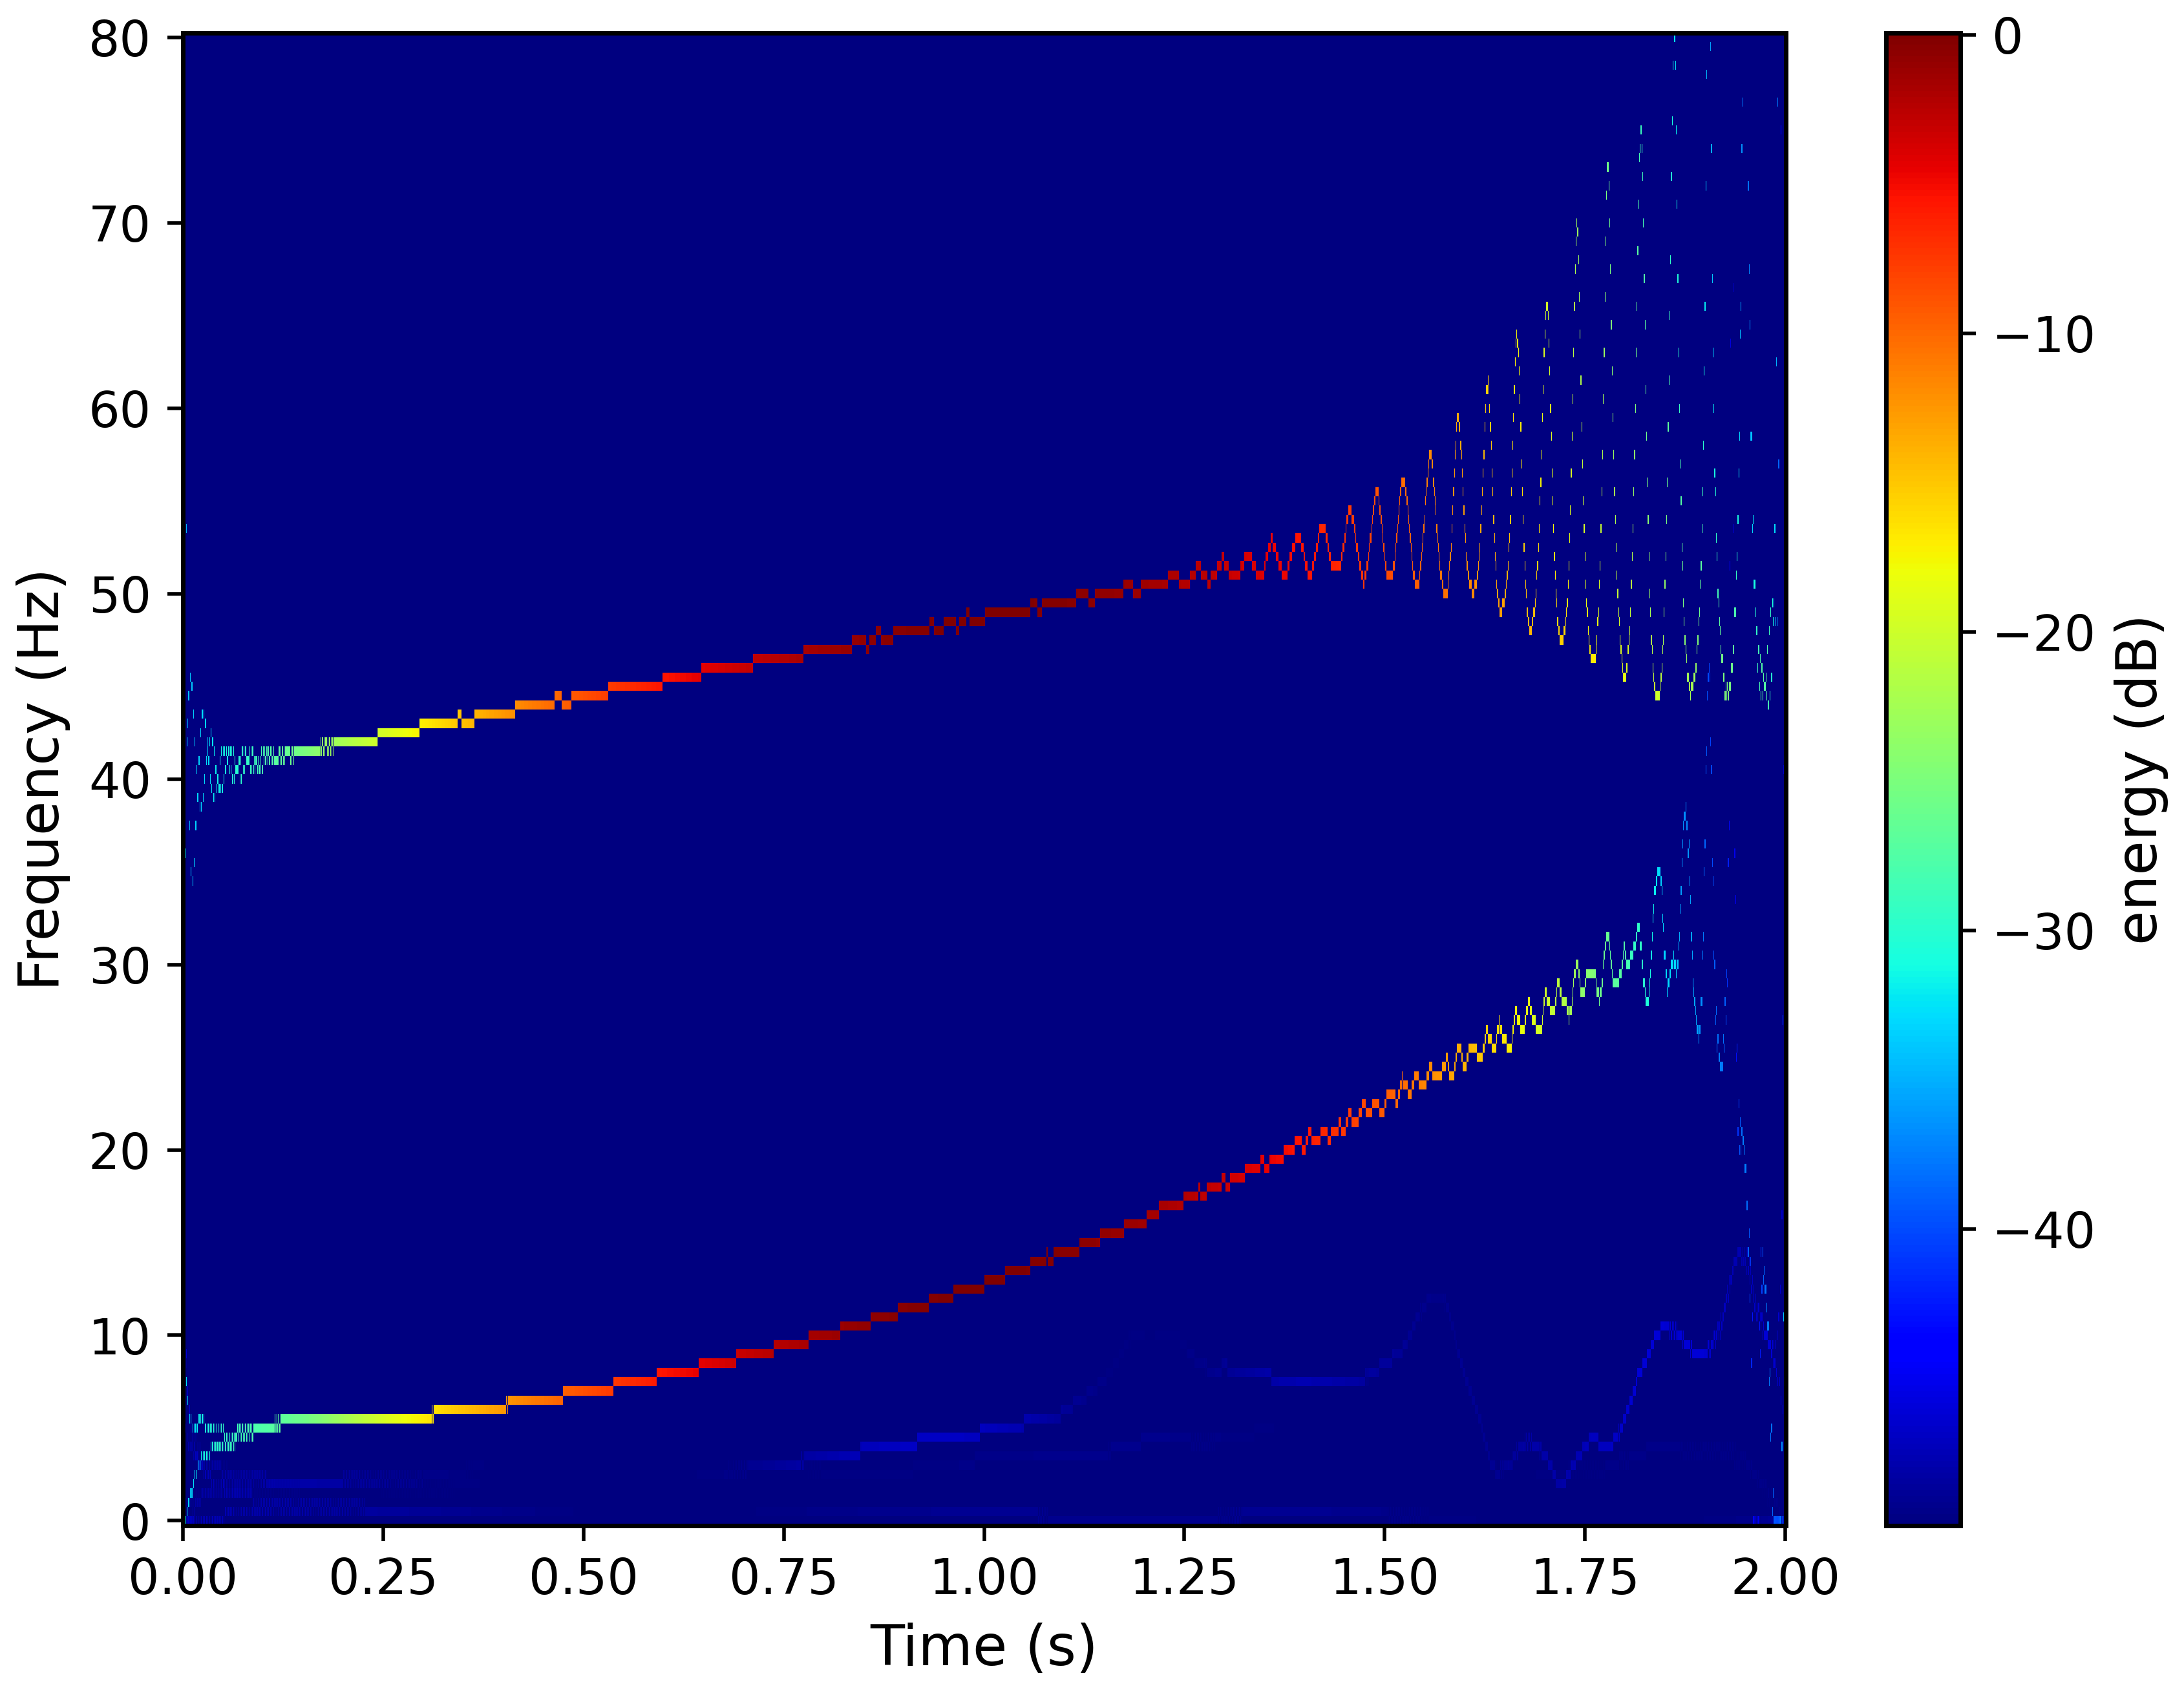

In [5]:
n_imf = imfs.shape[0]
fig, axs = plt.subplots(n_imf, 2, figsize=(11, 2.0 * n_imf), sharex=True)
if n_imf == 1:
    axs = np.array([axs])
for k in range(n_imf):
    axs[k, 0].plot(t, imfs[k], "k", lw=0.8, alpha=0.7)
    axs[k, 0].plot(t, imfs_env[k], "C3", lw=1.0)
    axs[k, 0].plot(t, -imfs_env[k], "C3", lw=1.0)
    axs[k, 0].set_ylabel(f"IMF{k+1}")
    axs[k, 1].plot(t, imfs_freq[k], color="C0", lw=0.9)
    axs[k, 1].set_ylabel("Hz")
    axs[k, 1].set_ylim(0, 80)
axs[0, 0].set_title("IMF + envelope")
axs[0, 1].set_title("Instantaneous frequency")
axs[-1, 0].set_xlabel("Time [s]")
axs[-1, 1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

# Hilbert spectrum via HHT helper
spectrum, t_axis, f_axis = hht.hilbert_spectrum(
    imfs_env=imfs_env,
    imfs_freq=imfs_freq,
    fs=fs,
    freq_lim=(0, 80),
    freq_res=0.5,
)
print("Hilbert spectrum shape (time, freq):", spectrum.shape)

plot_HilbertSpectrum(spectrum, t_axis, f_axis)
plt.suptitle("Hilbert spectrum H(t, f) of test_hht", y=1.02)
plt.show()

# Equivalent convenience API
hht.plot_spectrum(freq_lim=(0, 80), freq_res=0.5)
plt.show()

## 7. Experiment 3: Nonlinear Duffing-type oscillator

Paper §II-A1 discusses the Duffing oscillator as a canonical nonlinear system with time-varying instantaneous frequency. PySDKit provides `test_univariate_duffing`:
$$
x''+0.3x'+4x-0.6x^3=2\cos(2\pi\cdot 1.1\,t).
$$


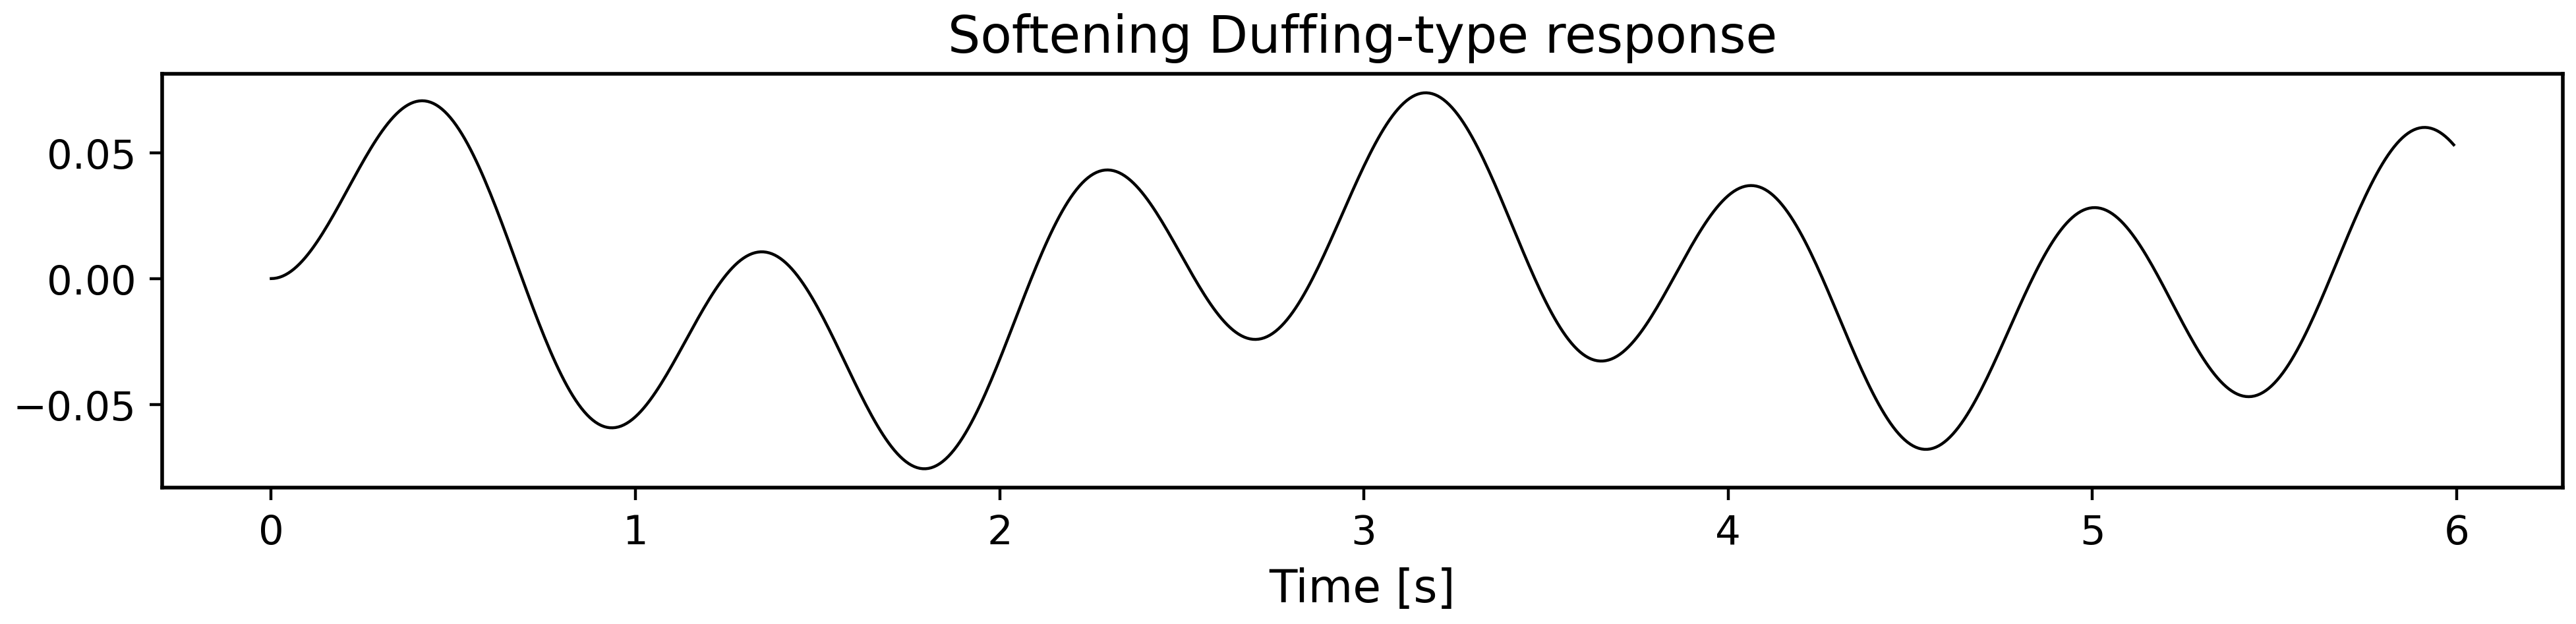

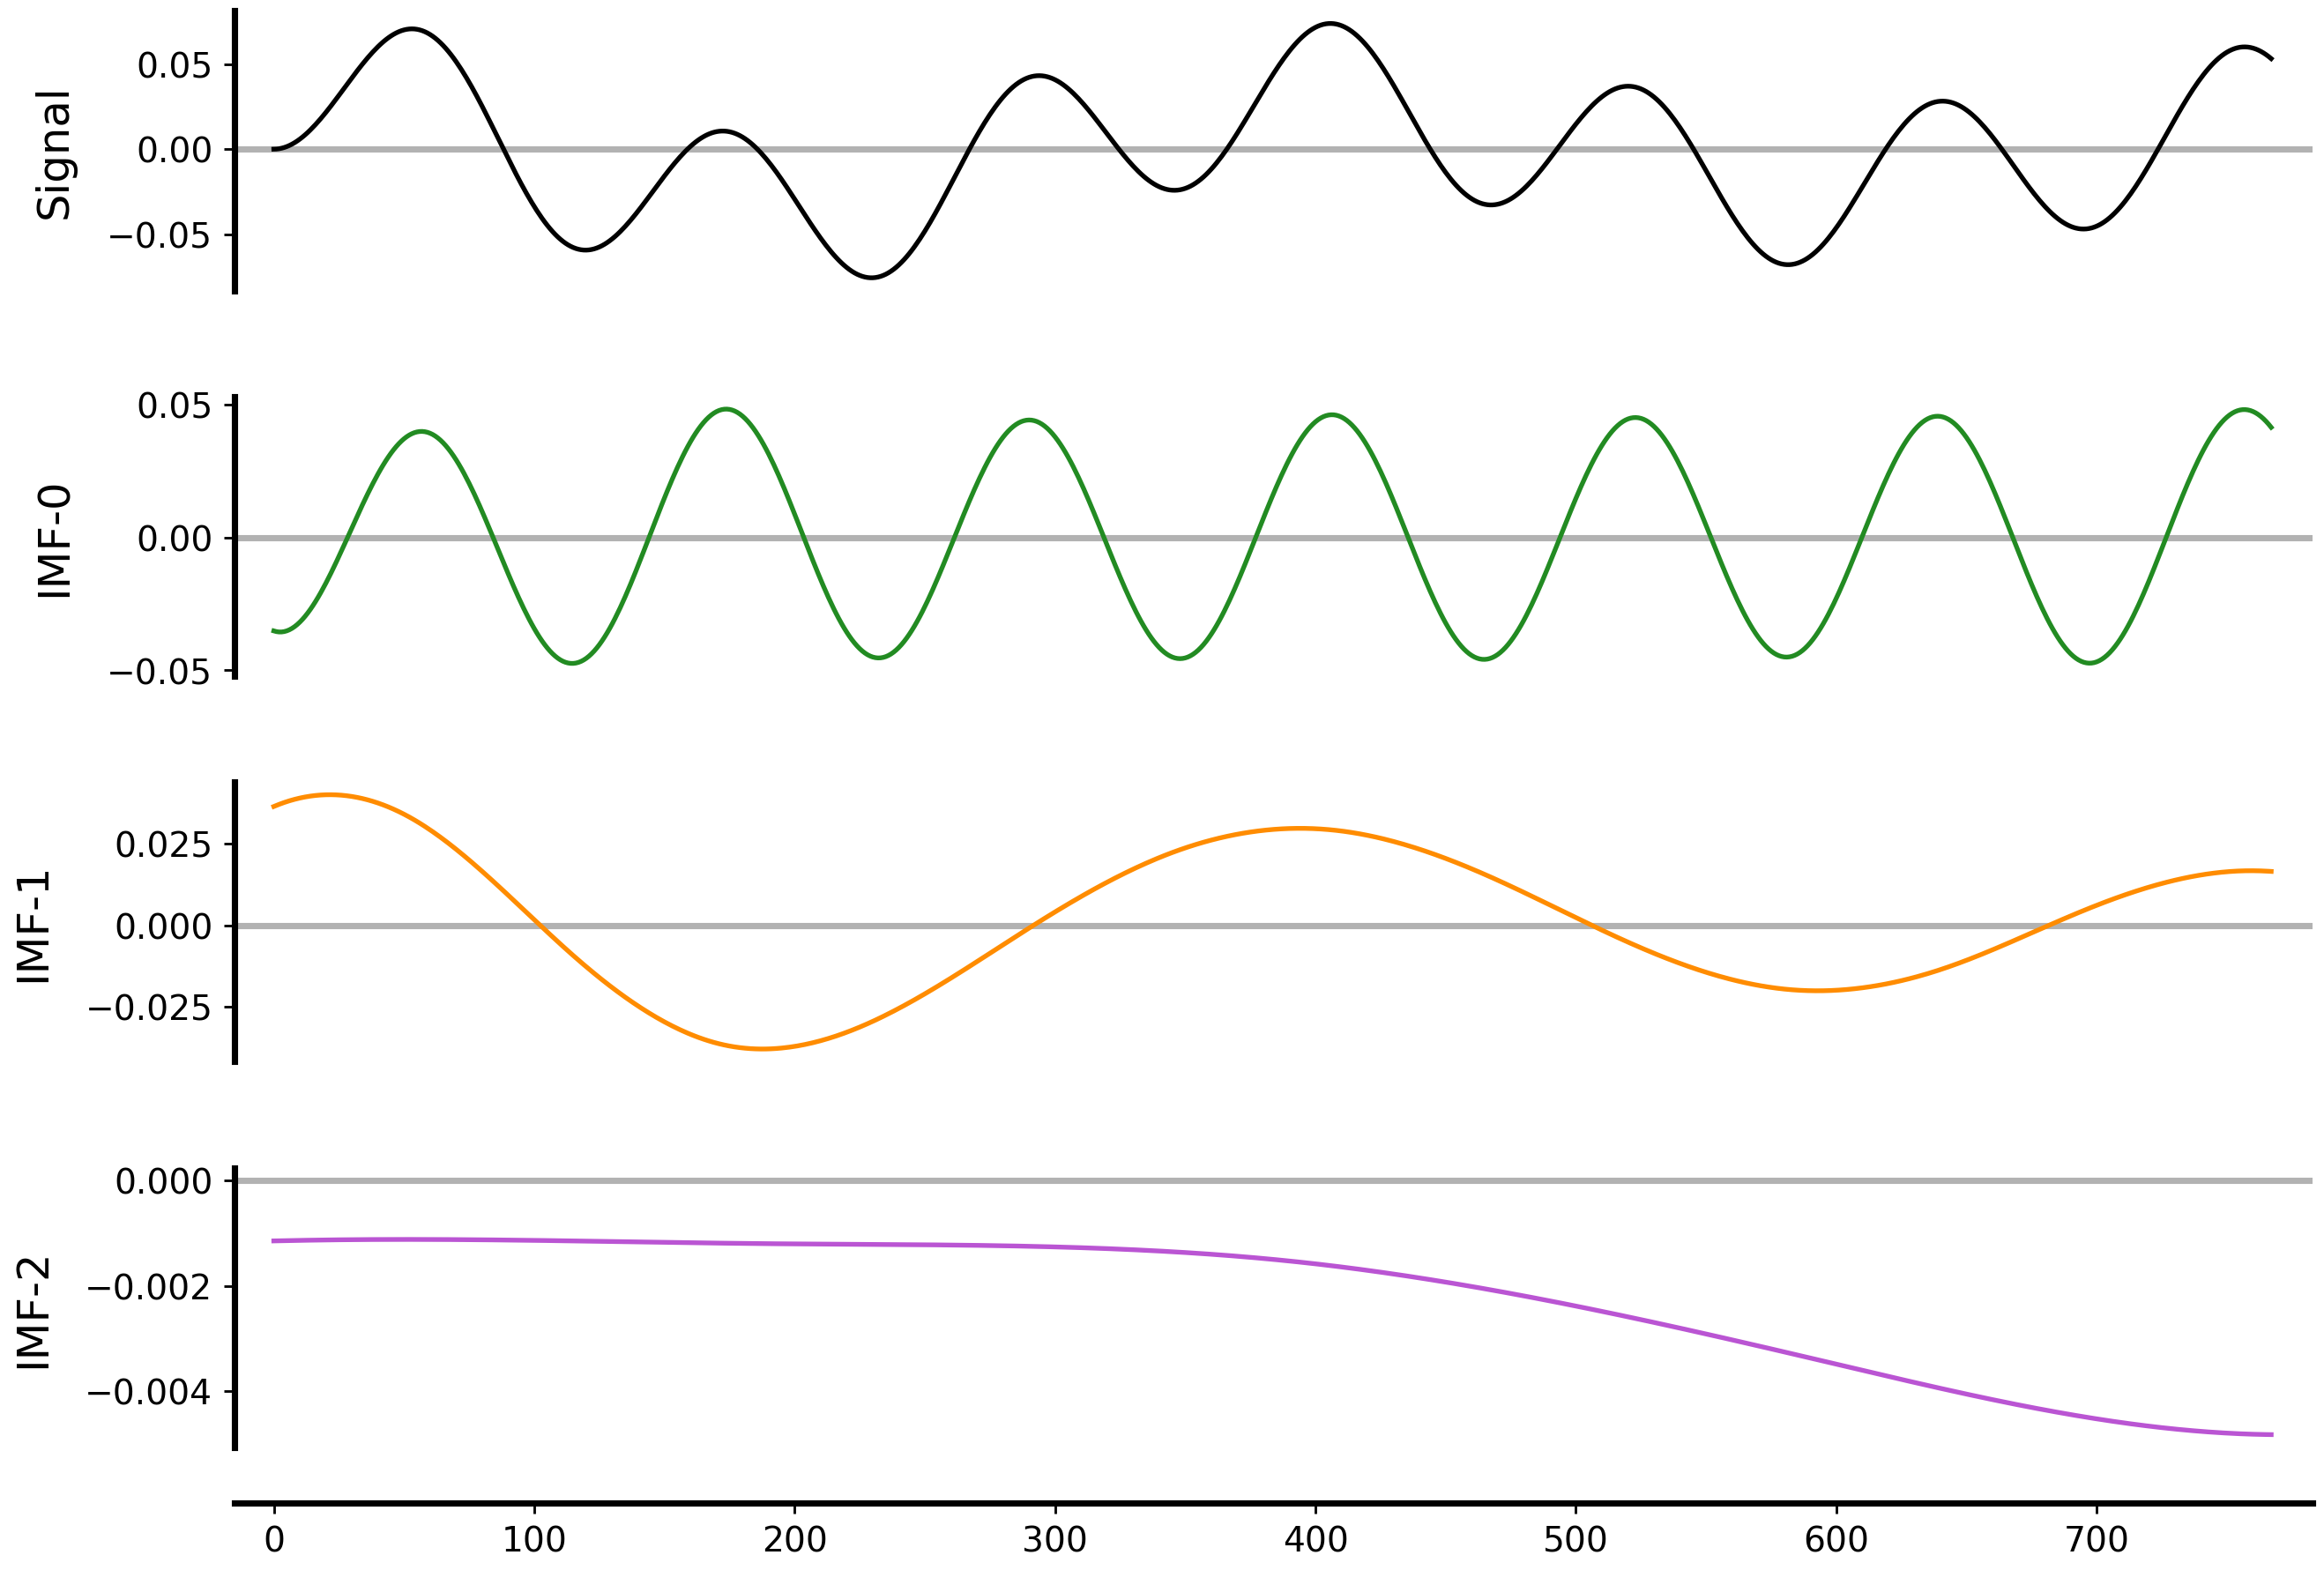

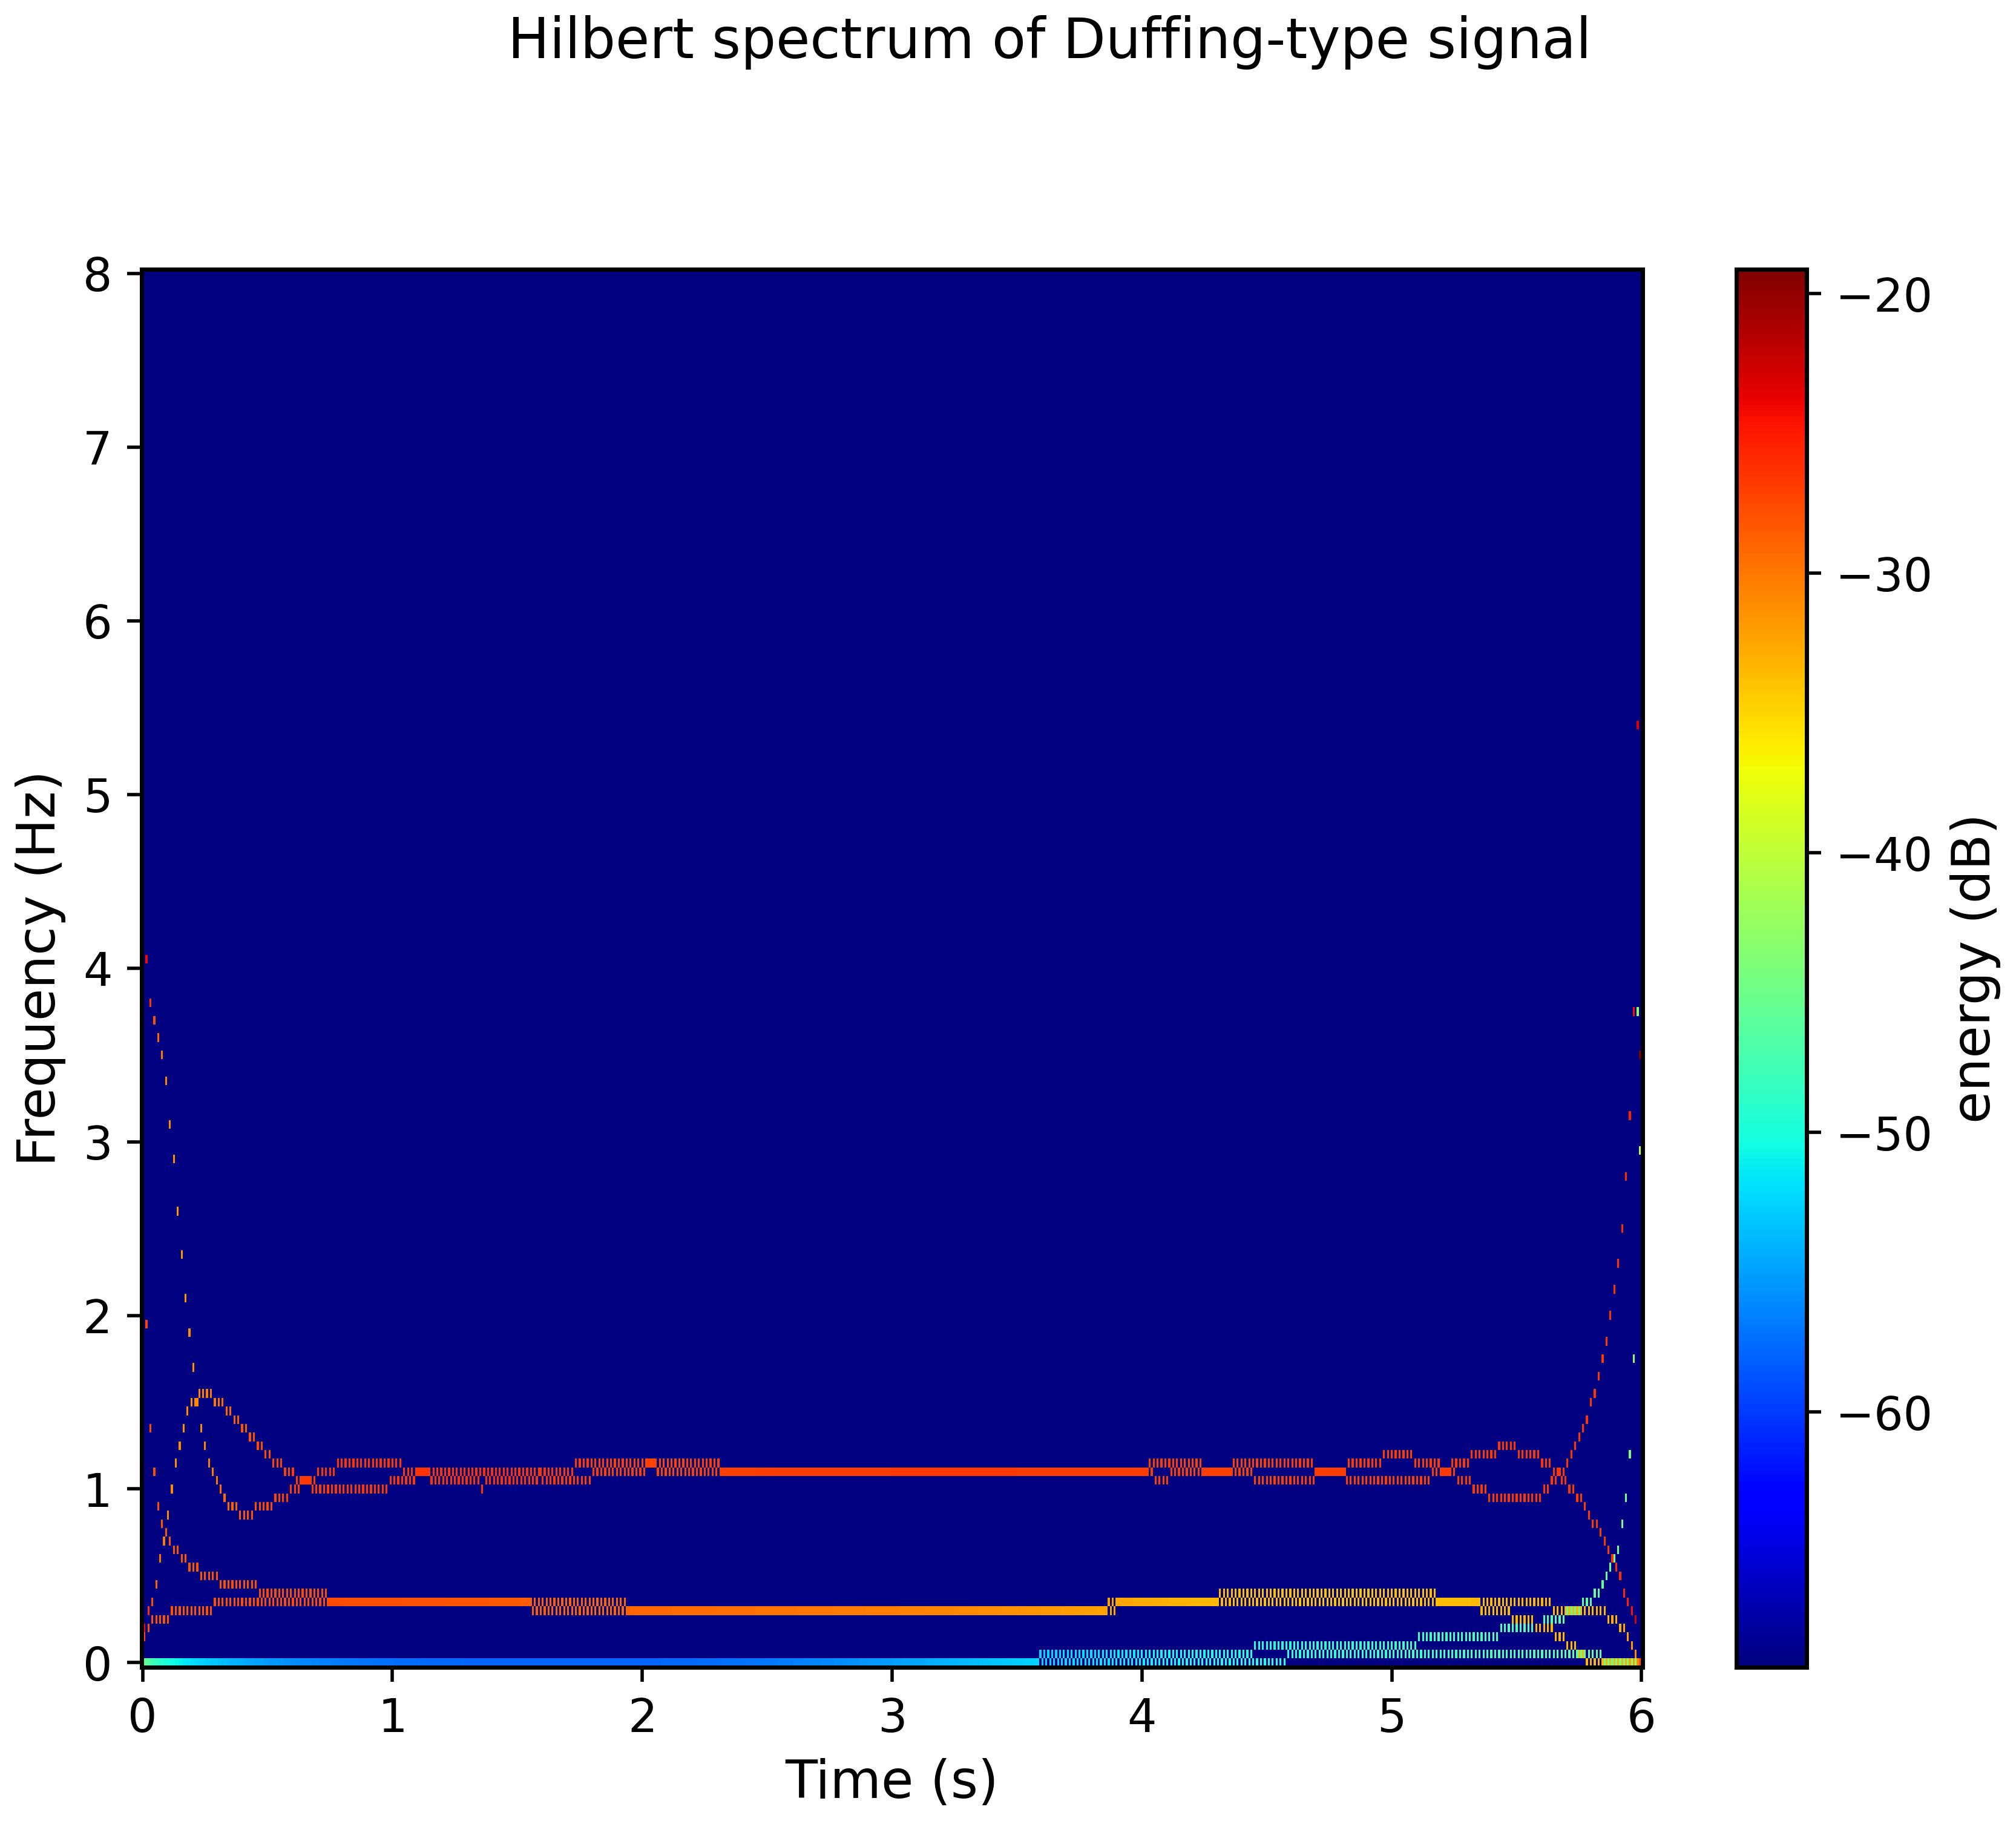

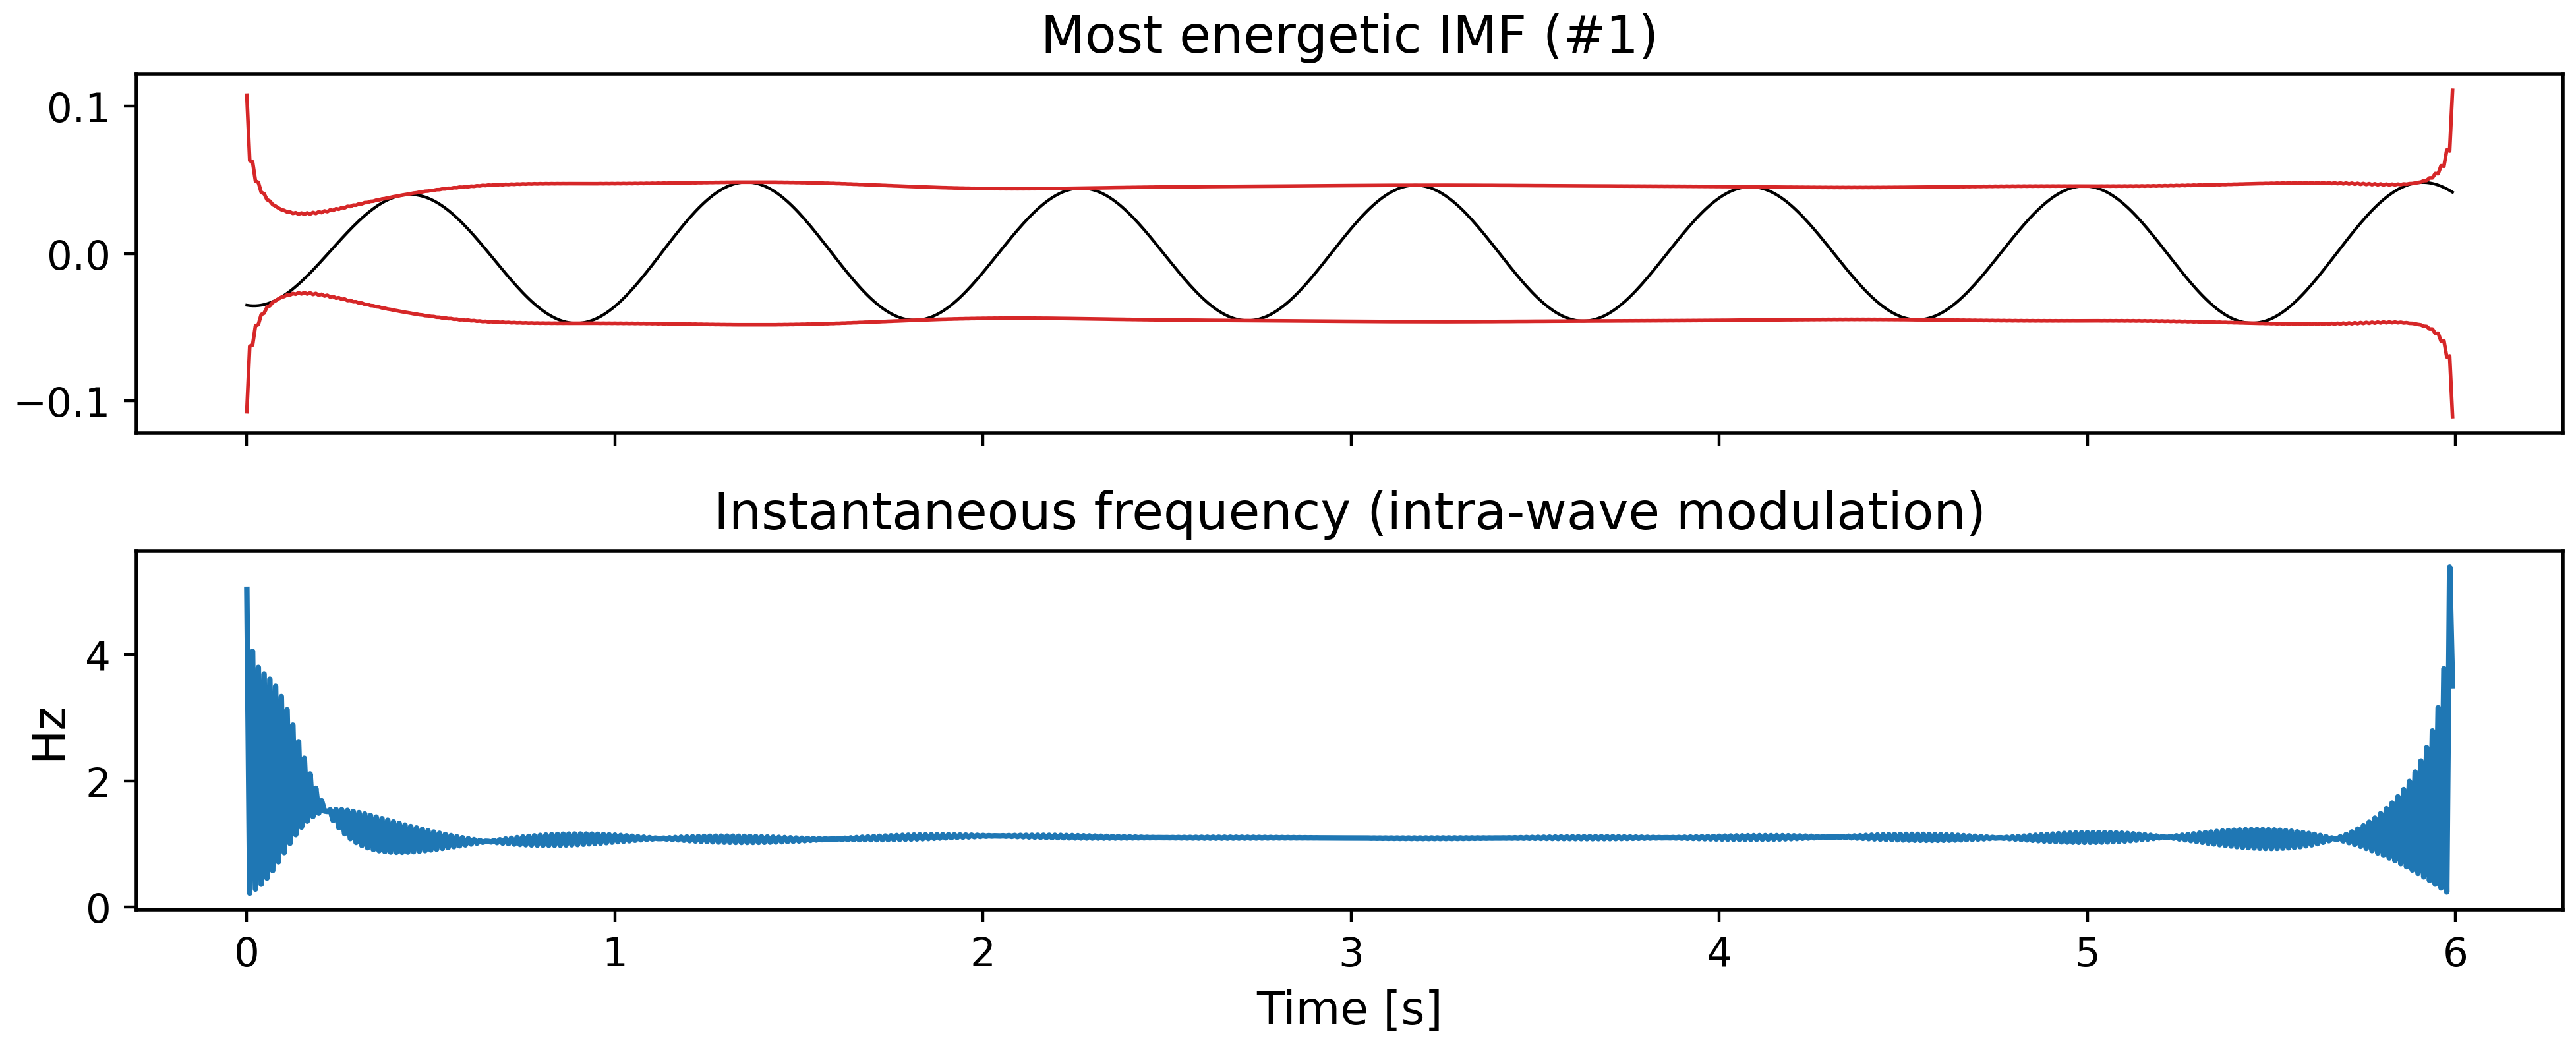

In [6]:
t_d, x_d = test_univariate_duffing(duration=6.0, sampling_rate=128, noise_level=0.0)
fs_d = 128.0

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.plot(t_d, x_d, "k", lw=0.8)
ax.set_title("Softening Duffing-type response")
ax.set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

hht_d = HHT(algorithm="EMD", max_imfs=4)
imfs_d, env_d, freq_d = hht_d.fit_transform(x_d, fs=fs_d, return_all=True)
fig = plot_IMFs(x_d, imfs_d, return_figure=True)
plt.show()

spectrum_d, td, fd = hht_d.hilbert_spectrum(
    freq_lim=(0, 8),
    freq_res=0.05,
)
plot_HilbertSpectrum(spectrum_d, td, fd)
plt.suptitle("Hilbert spectrum of Duffing-type signal", y=1.02)
plt.show()

# Track IF of the most energetic IMF
energies = np.sum(imfs_d**2, axis=1)
k_star = int(np.argmax(energies))
fig, axs = plt.subplots(2, 1, figsize=(10, 4.2), sharex=True)
axs[0].plot(t_d, imfs_d[k_star], "k", lw=0.8)
axs[0].plot(t_d, env_d[k_star], "C3", lw=1.0)
axs[0].plot(t_d, -env_d[k_star], "C3", lw=1.0)
axs[0].set_title(f"Most energetic IMF (#{k_star+1})")
axs[1].plot(t_d, freq_d[k_star], color="C0")
axs[1].set_ylabel("Hz")
axs[1].set_xlabel("Time [s]")
axs[1].set_title("Instantaneous frequency (intra-wave modulation)")
plt.tight_layout()
plt.show()

## 8. Experiment 4: HHT vs STFT spectrogram

Fourier-based spectrograms use a fixed window and therefore face a rigid time–frequency resolution trade-off. The Hilbert spectrum, built from adaptive IMFs, can follow chirps more sharply when modes are well separated.


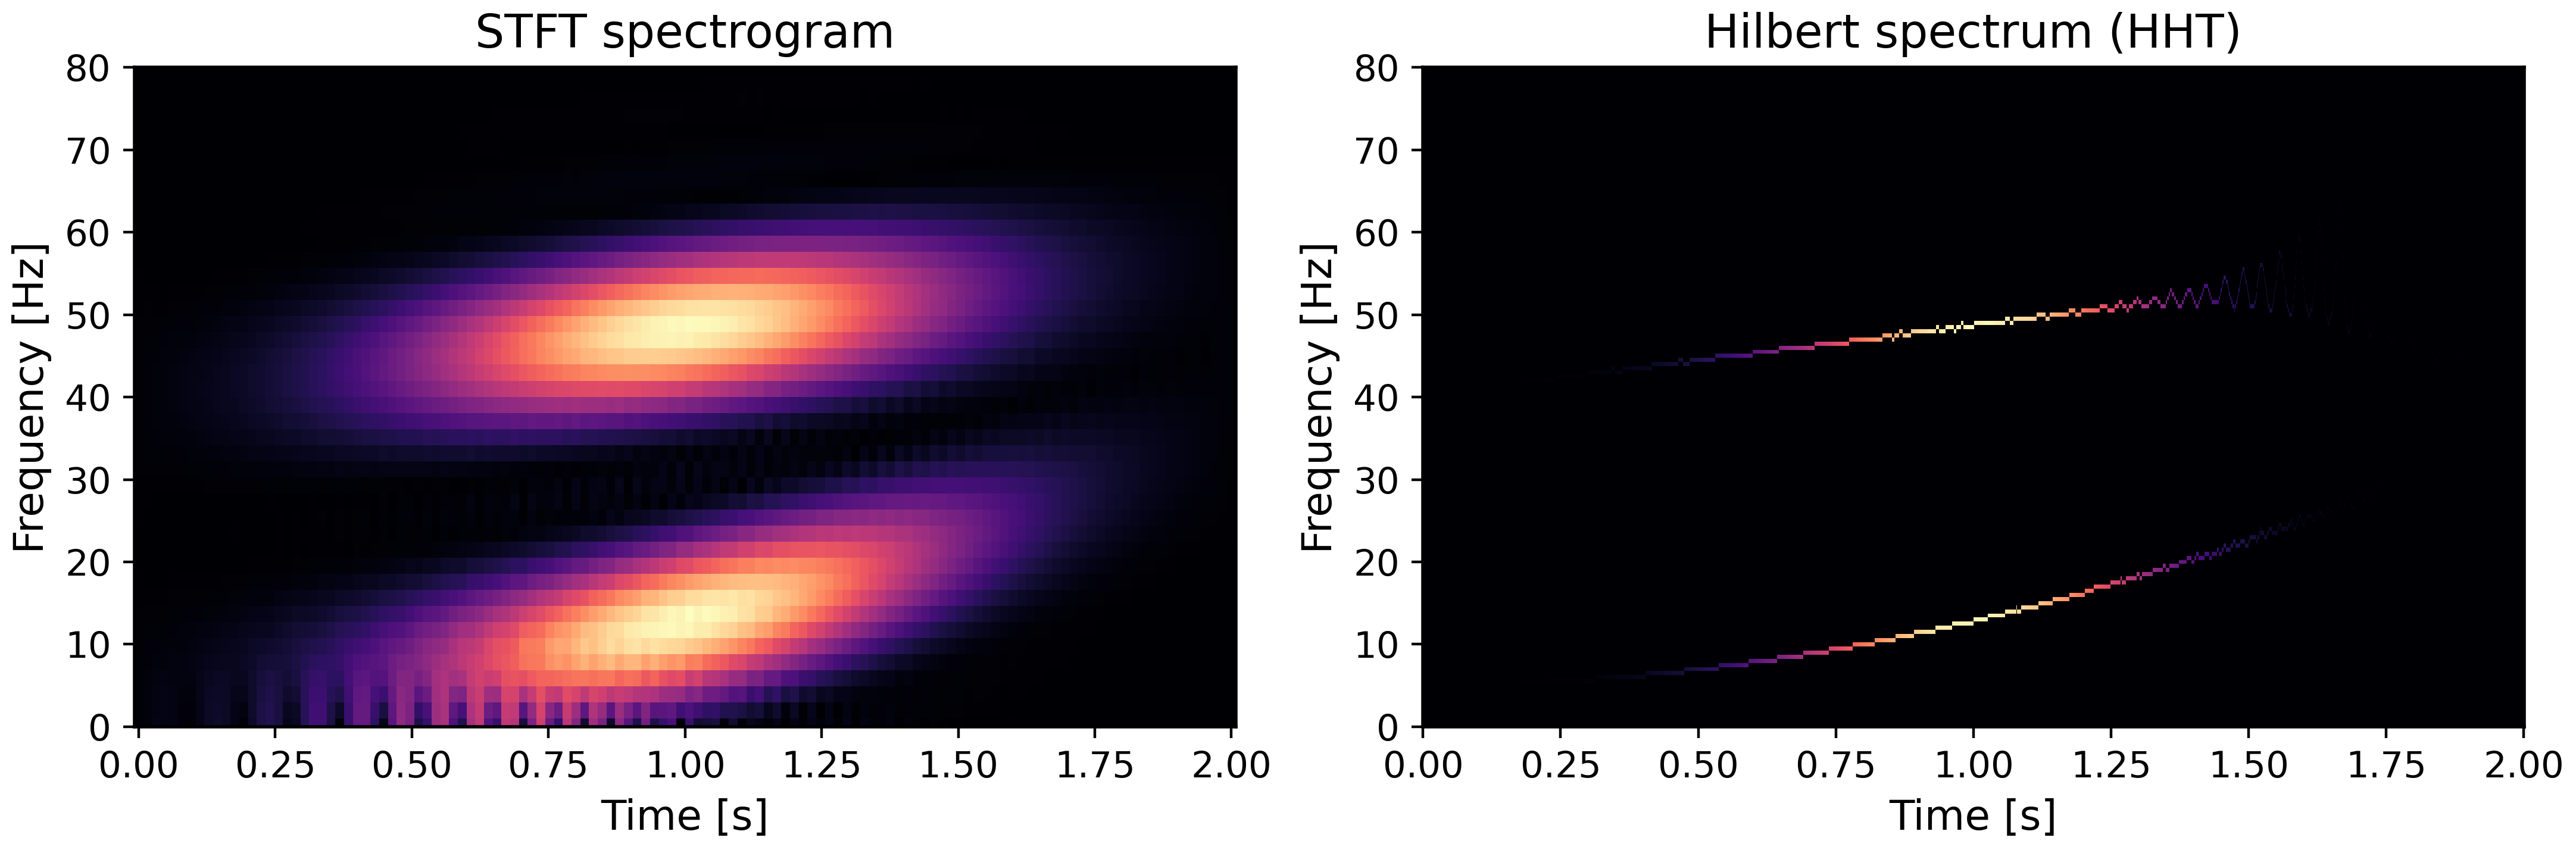

In [7]:
f_stft, t_stft, Zxx = stft(signal, fs=fs, nperseg=128, noverlap=112, nfft=512)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.8))
axs[0].pcolormesh(t_stft, f_stft, np.abs(Zxx), shading="auto", cmap="magma")
axs[0].set_ylim(0, 80)
axs[0].set_xlabel("Time [s]")
axs[0].set_ylabel("Frequency [Hz]")
axs[0].set_title("STFT spectrogram")

axs[1].pcolormesh(t_axis, f_axis, spectrum.T, shading="auto", cmap="magma")
axs[1].set_ylim(0, 80)
axs[1].set_xlabel("Time [s]")
axs[1].set_ylabel("Frequency [Hz]")
axs[1].set_title("Hilbert spectrum (HHT)")
plt.tight_layout()
plt.show()

## 9. Summary

1. **HHT = EMD + Hilbert analysis**: EMD supplies mono-component IMFs; Hilbert analysis extracts $a_n(t)$ and $f_n(t)$.  
2. **Analytic signal**: $z=x+j\mathcal{H}\{x\}=a e^{j\theta}$ enables instantaneous features.  
3. **Hilbert spectrum** $H(t,f)$ accumulates IMF energy on the time–frequency plane.  
4. **Use cases**: chirps, nonlinear oscillators (Duffing), biomedical non-stationary recordings.  
5. **Practice with PySDKit**:
   - `HHT(algorithm='EMD', max_imfs=...)`
   - `fit_transform(..., fs=fs, return_all=True)` → `(imfs, envelopes, freqs)`
   - `plot_spectrum(...)` / `hilbert_spectrum(...)`

### One-liner

```python
from pysdkit import HHT
from pysdkit.data import test_hht

t, x = test_hht()
hht = HHT(max_imfs=4)
imfs, env, freq = hht.fit_transform(x, fs=1000, return_all=True)
hht.plot_spectrum(freq_lim=(0, 80))
```

### Related notebooks

- `examples/emd.ipynb` — full sifting pipeline with envelope visualizations  
- `examples/vmd.ipynb` — variational alternative to EMD  
